# Project Overview: Equine Population Analysis in the Czech Republic

## Introduction
The aim of this project is to analyze the evolution of the horse population in the Czech Republic. The dataset represents a time series spanning from 1921 to 2025. The source of the data is the Czech Statistical Office (CSO) and the Central Register of Horses (ÚEK).

From 1921 to 2001, the data was collected only by the CSO. These data represent all registered horses. After 2001, a change occurred and the CSO registered only a part of the horse population, excluding hobby horses. Since then, ÚEK has provided a comprehensive overview of the total horse population, as registration with the ÚEK is mandatory for all horse owners by law..

## Dataset Description
The dataset contains the following columns:
- **`year`** – The recorded year.
- **`horse_count`** – The number of registered horses.

## Project Goals
In this project, I aim to:
- Analyze the data.
- Interpolate missing values.
- Visualize the dataset.
- Forecast the horse population up to 2050
- **Create an animated video using the Manim library to showcase the evolution of the horse population over time**.

**1) Required libraries**

In [ ]:
# Prophet installation package
!pip uninstall -y prophet cmdstanpy

!pip install cmdstanpy==1.0.8
!pip install prophet

from cmdstanpy import install_cmdstan
install_cmdstan()

Found existing installation: prophet 1.3.0
Uninstalling prophet-1.3.0:
  Successfully uninstalled prophet-1.3.0
Found existing installation: cmdstanpy 1.3.0
Uninstalling cmdstanpy-1.3.0:
  Successfully uninstalled cmdstanpy-1.3.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.2/81.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 96.4 MB/s eta 0:00:00
Installing CmdStan version: 2.38.0
Install directory: /root/.cmdstan
Download successful, file: /tmp/tmp9qbo5emm
Extracting distribution


DEBUG:cmdstanpy:cmd: make build -j1
cwd: None


Unpacked download as cmdstan-2.38.0
Building version cmdstan-2.38.0, may take several minutes, depending on your system.


DEBUG:cmdstanpy:cmd: make examples/bernoulli/bernoulli
cwd: None


Test model compilation
Installed cmdstan-2.38.0


True

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import json
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly, add_changepoints_to_plot
from prophet.diagnostics import cross_validation, performance_metrics

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**2) Data upload**

In [ ]:
FILE = "/content/drive/MyDrive/01_data_science/03_projects/01_horses_population/horse_population_analysis/data/raw.csv"
df = pd.read_csv(FILE)

**3) EDA**

In [ ]:
print("DF shape:", df.shape)
print(f"\nDF preview:")
display(df.head(10))
print(f"\nDF info:")
df.info()

DF shape: (105, 2)

DF preview:


,year,horse_count
0,1921,385806.0
1,1922,NaN
2,1923,NaN
3,1924,NaN
4,1925,NaN
5,1926,455757.0
6,1927,NaN
7,1928,NaN
8,1929,NaN
9,1930,NaN



DF info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   year         105 non-null    int64  
 1   horse_count  89 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.8 KB


In [ ]:
miss_count = df.isna().sum()
miss_percent = df.isna().sum() / len(df) * 100
miss_df = pd.DataFrame({"missing_count": miss_count, "missing_percentage": miss_percent})
display(miss_df)

,missing_count,missing_percentage
year,0,0.000000
horse_count,16,15.238095


In [ ]:
miss_year = df[df["horse_count"].isna()]["year"]
print("Missing years:")
display(miss_year)

Missing years:


,year
1,1922
2,1923
3,1924
4,1925
6,1927
7,1928
8,1929
9,1930
10,1931
11,1932


In [ ]:
# Calculation of the length of missing data blocks.
miss_year_s = pd.Series(miss_year)
group_id = (miss_year_s.diff() != 1).cumsum()
miss_year_summary = miss_year_s.groupby(group_id).agg(["min", "max", "count"])
for _, row in miss_year_summary.iterrows():
    print(f"Block {row['min']} to {row['max']}: length {row['count']} year")

Block 1922 to 1925: length 4 year
Block 1927 to 1932: length 6 year
Block 1939 to 1944: length 6 year


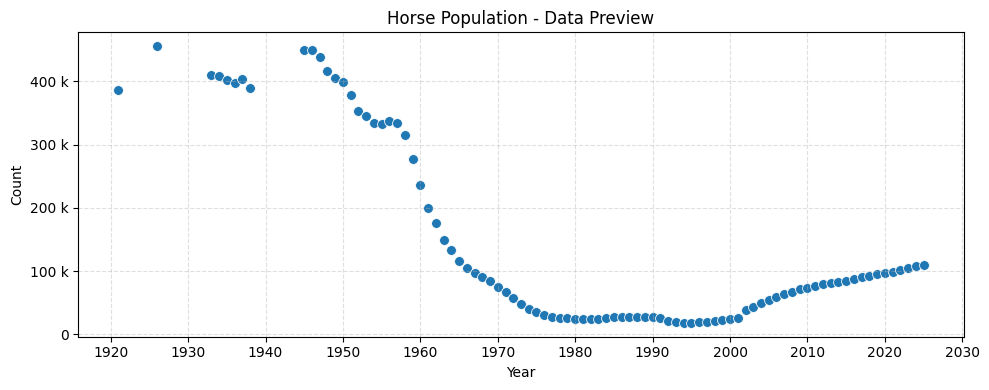

In [ ]:
"""
Overall, data are missing for 15% of the years. The missing values occur in the first quarter of the time series.
Data gaps correspond to the period between the World Wars and during the Second World War.
"""

plt.figure(figsize=(10, 4))
sns.scatterplot(df, x="year", y="horse_count",s=50)
plt.title("Horse Population - Data Preview")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.4)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.show()

**3.1.) Estimation of missing values**      
I will interpolate the missing values using the following methods:      
- Linear interpolation      
- Polynomial interpolation (2nd- and 3rd-order)  

Then, I will perform a quantitative error measurement using cross-validation.

In [ ]:
df.set_index("year", inplace=True)

# Linear and polynomial interpolation (using Pandas)
df["horse_count_linear"] = df["horse_count"].interpolate(method="linear")
df["horse_count_poly_quadratic"] = df["horse_count"].interpolate(method="polynomial", order=2) # quadratic
df["horse_count_poly_cubic"] = df["horse_count"].interpolate(method="polynomial", order=3) # cubic

In [ ]:
# Check whether the missing values have been filled in
print(df.isna().sum())

horse_count                   16
horse_count_linear             0
horse_count_poly_quadratic     0
horse_count_poly_cubic         0
dtype: int64


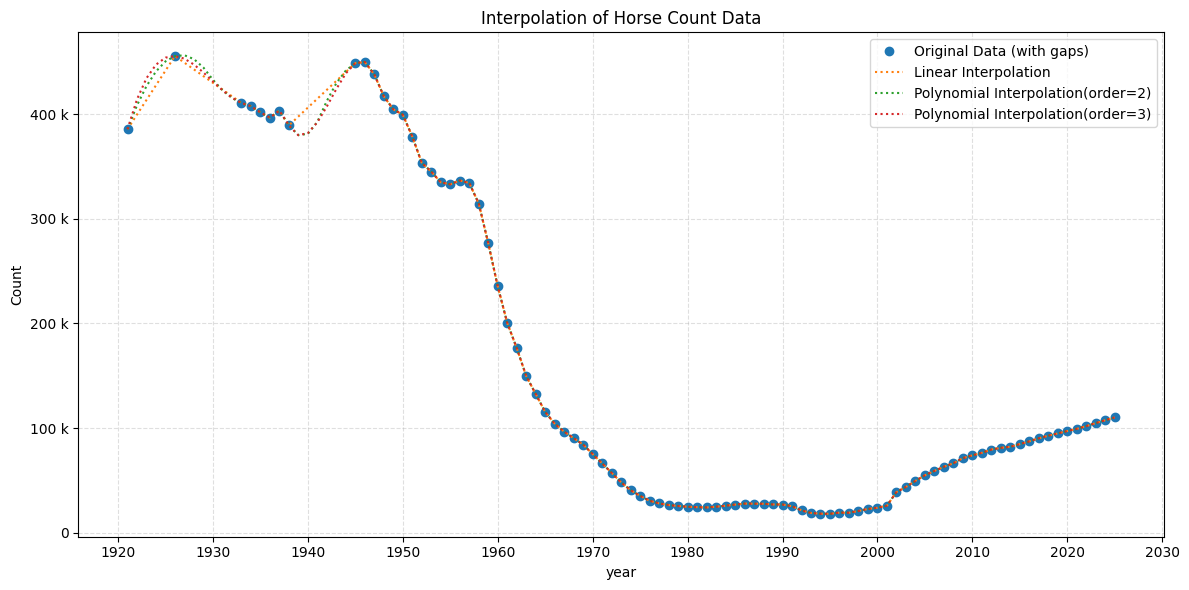

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df["horse_count"], "o", label="Original Data (with gaps)")
plt.plot(df["horse_count_linear"], ":", label="Linear Interpolation")
plt.plot(df["horse_count_poly_quadratic"], ":", label="Polynomial Interpolation(order=2)")
plt.plot(df["horse_count_poly_cubic"], ":", label="Polynomial Interpolation(order=3)")
plt.xlabel("year")
plt.ylabel("Count")
plt.title("Interpolation of Horse Count Data")
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Rolling Window Cross-Validation
"""
The data is missing in blocks, not in individual points.
For this reason, I will test the accuracy of interpolation on many 5-year blocks.
The selected block length is based on the length of the actual blocks of missing data.
"""
validation_subset = df.loc[1945:2025].copy()
window_size = 5

# Setting the boards
start_year = validation_subset.index.min() + 2
end_year = validation_subset.index.max() - window_size - 2

# Preparation for Residual calculation
residuals_data = {
    "linear": [],
    "quadratic": [],
    "cubic": []
}

In [ ]:
results = []

for year in range(start_year, end_year):
    temp_df = validation_subset.copy()

    # Gap definition
    gap_indices = list(range(year, year + window_size))
    actual_values = temp_df.loc[gap_indices, "horse_count"].values

    # Deletion of data
    temp_df.loc[gap_indices, "horse_count"] = np.nan

    # Interpolation
    linear_vals = temp_df["horse_count"].interpolate(method="linear").loc[gap_indices].values
    poly2_vals = temp_df["horse_count"].interpolate(method="polynomial", order=2).loc[gap_indices].values
    poly3_vals = temp_df["horse_count"].interpolate(method="polynomial", order=3).loc[gap_indices].values

    # Residual calculation
    residuals_data["linear"].extend(actual_values - linear_vals)
    residuals_data["quadratic"].extend(actual_values - poly2_vals)
    residuals_data["cubic"].extend(actual_values - poly3_vals)

    # Saving results
    results.append({
      "Linear MAE": mean_absolute_error(actual_values, linear_vals),
      "Linear RMSE": np.sqrt(mean_squared_error(actual_values, linear_vals)),

      "Quadratic MAE": mean_absolute_error(actual_values, poly2_vals),
      "Quadratic RMSE": np.sqrt(mean_squared_error(actual_values, poly2_vals)),

      "Cubic MAE": mean_absolute_error(actual_values, poly3_vals),
      "Cubic RMSE": np.sqrt(mean_squared_error(actual_values, poly3_vals)),
    })
results_df = pd.DataFrame(results)

In [ ]:
avg_val = results_df.mean()

summary_df_val = pd.DataFrame({
  "MAE": [avg_val["Linear MAE"], avg_val["Quadratic MAE"], avg_val["Cubic MAE"]],
  "RMSE": [avg_val["Linear RMSE"], avg_val["Quadratic RMSE"], avg_val["Cubic RMSE"]]
}, index=["Linear", "Quadratic", "Cubic"])

print("Average Metrics")
print(summary_df_val.round(0))

Average Metrics
              MAE    RMSE
Linear     5227.0  5704.0
Quadratic  3216.0  3633.0
Cubic      3181.0  3591.0


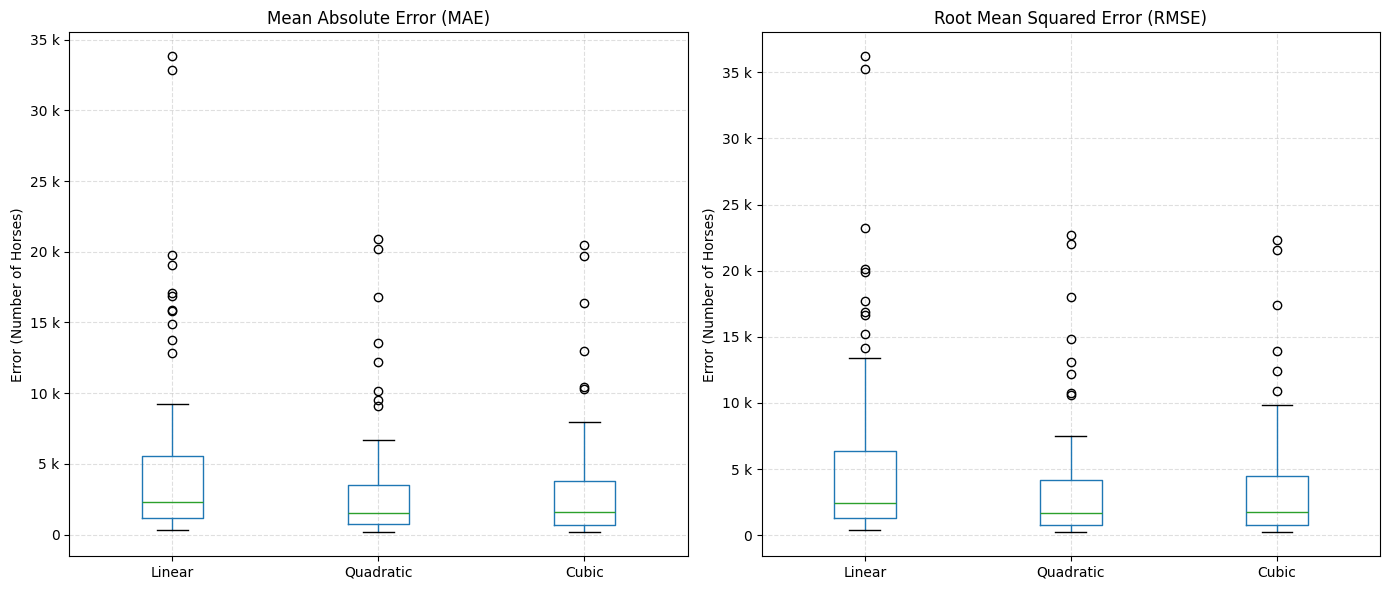

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

groups = [
    (["Linear MAE", "Quadratic MAE", "Cubic MAE"], "Mean Absolute Error (MAE)"),
    (["Linear RMSE", "Quadratic RMSE", "Cubic RMSE"], "Root Mean Squared Error (RMSE)")
]

for ax, (col_names, title) in zip(axes, groups):
    results_df[col_names].boxplot(ax=ax)
    ax.set_title(title)
    ax.set_ylabel("Error (Number of Horses)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.yaxis.set_major_formatter(ticker.EngFormatter())
    ax.set_xticklabels(["Linear", "Quadratic", "Cubic"])

plt.tight_layout()
plt.show()

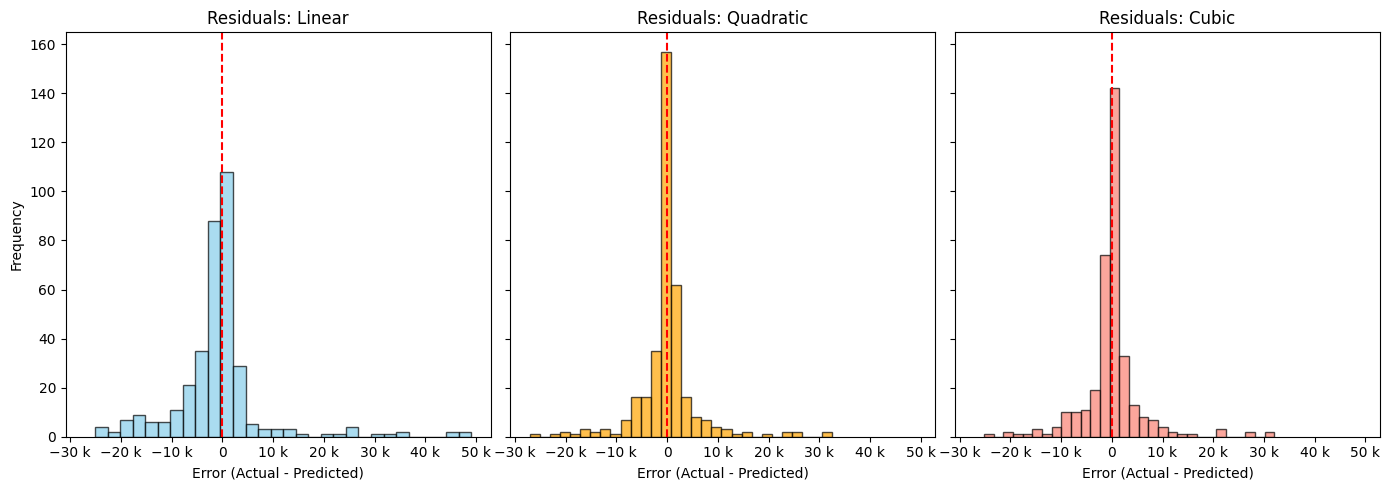

In [ ]:
# Residual visualization (Histogram)
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharex=True, sharey=True)

methods = [
    ("linear", "skyblue", "Linear"),
    ("quadratic", "orange", "Quadratic"),
    ("cubic", "salmon", "Cubic")
]

for ax, (key, color, title) in zip(axes, methods):
    ax.hist(residuals_data[key], bins=30, color=color, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--')
    ax.set_title(f"Residuals: {title}")
    ax.set_xlabel("Error (Actual - Predicted)")
    ax.xaxis.set_major_formatter(ticker.EngFormatter())

axes[0].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Based on the assessment of different methods, polynomial interpolation proved to be superior to linear interpolation. While both cubic and quadratic models performed well, I selected **quadratic polynomial interpolation** as the optimal method. Although the cubic model showed marginally lower MAE and RMSE values, the quadratic model offers greater stability and robustness against overfitting. The residual analysis supports this decision, showing that errors are centered around zero with no significant skew or systematic patterns.

**3.2.) Time series analysis with interpolated data**

In [ ]:
df.rename(columns={"horse_count_poly_quadratic": "Horses"}, inplace=True)
df["Horses"] = df["Horses"].round().astype(int)

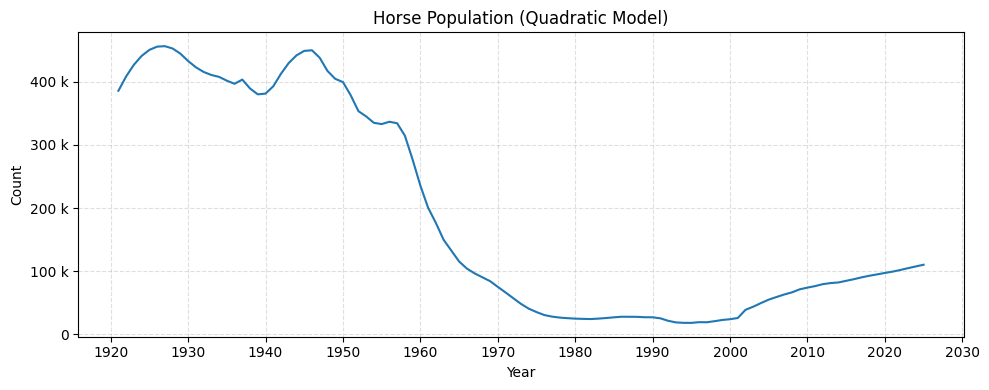

In [ ]:
plt.figure(figsize=(10, 4))
sns.lineplot(df["Horses"])
plt.title("Horse Population (Quadratic Model)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.4)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.show()

In [ ]:
# Calculating the year-over-year difference to assess absolute changes in horse population

df["horse_diff"] = df["Horses"].diff()

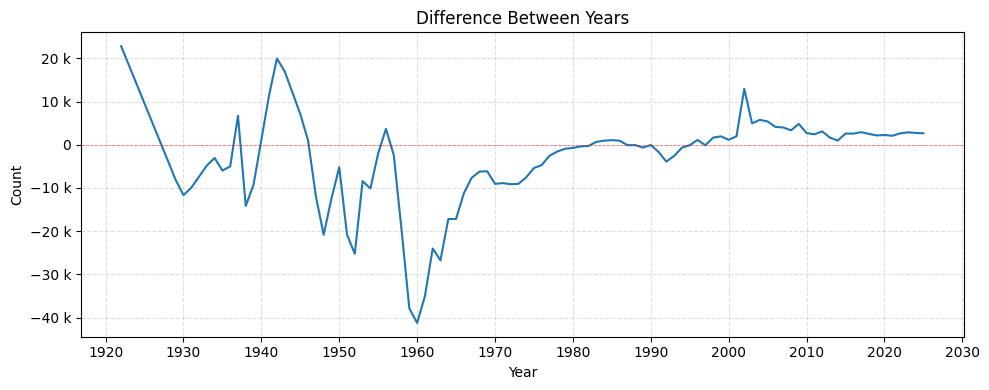

In [ ]:
plt.figure(figsize=(10, 4))
sns.lineplot(df["horse_diff"])
plt.title("Difference Between Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.axhline(0, color="red", linewidth=0.6, linestyle='--', alpha=0.5)
plt.grid(True, linestyle="--", alpha=0.4)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.show()

In [ ]:
# Calculating the year-over-year percentage change (Growth Rate)

df["horse_pct_change"] = df["Horses"].pct_change() * 100

In [ ]:
# Calculation of simple moving average to smooth short-term fluctuations

df["horse_percentage_SMA_5"] = df["horse_pct_change"].rolling(window=5).mean()

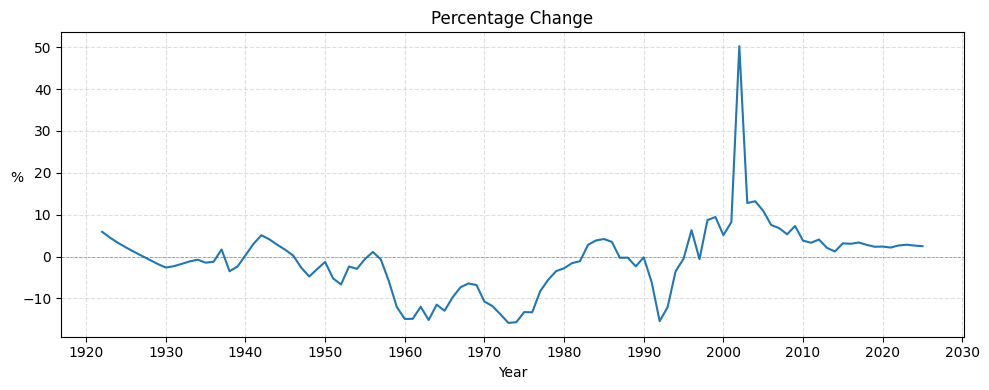

In [ ]:
plt.figure(figsize=(10, 4))
sns.lineplot(df["horse_pct_change"])
plt.title("Percentage Change")
plt.xlabel("Year")
plt.ylabel("%", rotation=0)
plt.axhline(0, color="red", linewidth=0.6, linestyle='--', alpha=0.5)
plt.grid(True, linestyle="--", alpha=0.4)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.tight_layout()
plt.show()

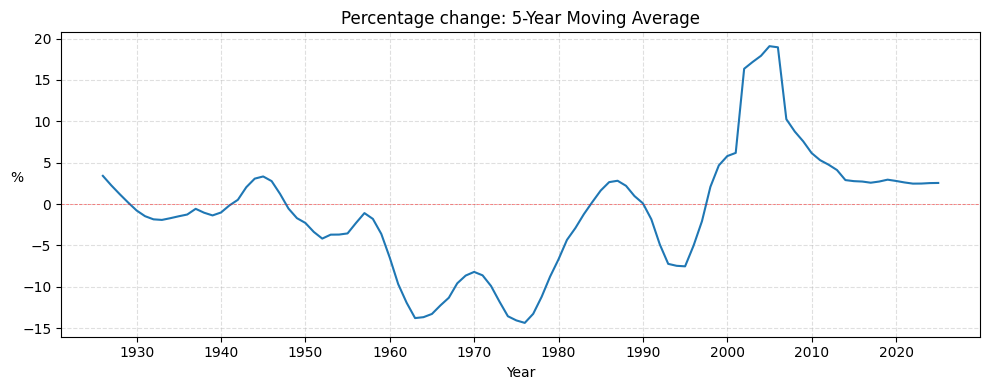

In [ ]:
plt.figure(figsize=(10, 4))
sns.lineplot(df["horse_percentage_SMA_5"])
plt.title("Percentage change: 5-Year Moving Average")
plt.xlabel("Year")
plt.ylabel("%",rotation=0)
plt.axhline(0, color='red', linewidth=0.6, linestyle='--', alpha=0.5)
plt.grid(True, linestyle="--", alpha=0.4)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.tight_layout()
plt.show()

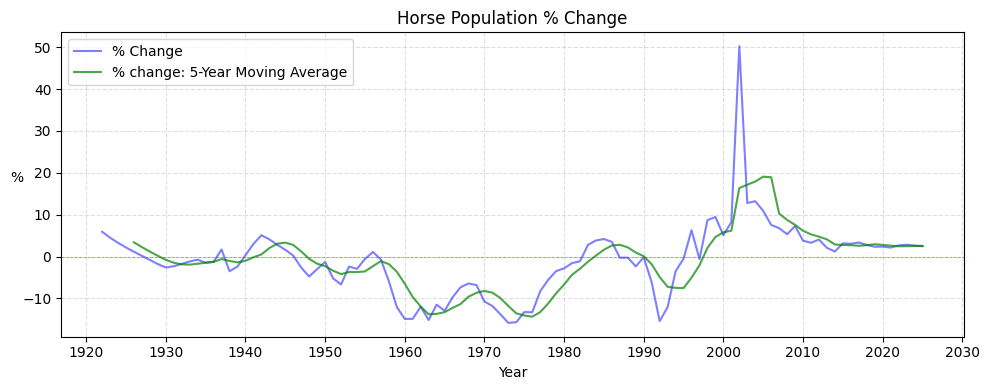

In [ ]:
plt.figure(figsize=(10, 4))
sns.lineplot(df["horse_pct_change"], color="blue", alpha=0.5, label="% Change")
sns.lineplot(df["horse_percentage_SMA_5"], color="green", alpha=0.7, label="% change: 5-Year Moving Average")
plt.title("Horse Population % Change")
plt.xlabel("Year")
plt.ylabel("%", rotation=0)
plt.axhline(0, color="red", linewidth=0.6, linestyle='--', alpha=0.5)
plt.grid(True, linestyle="--", alpha=0.4)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.tight_layout()
plt.show()

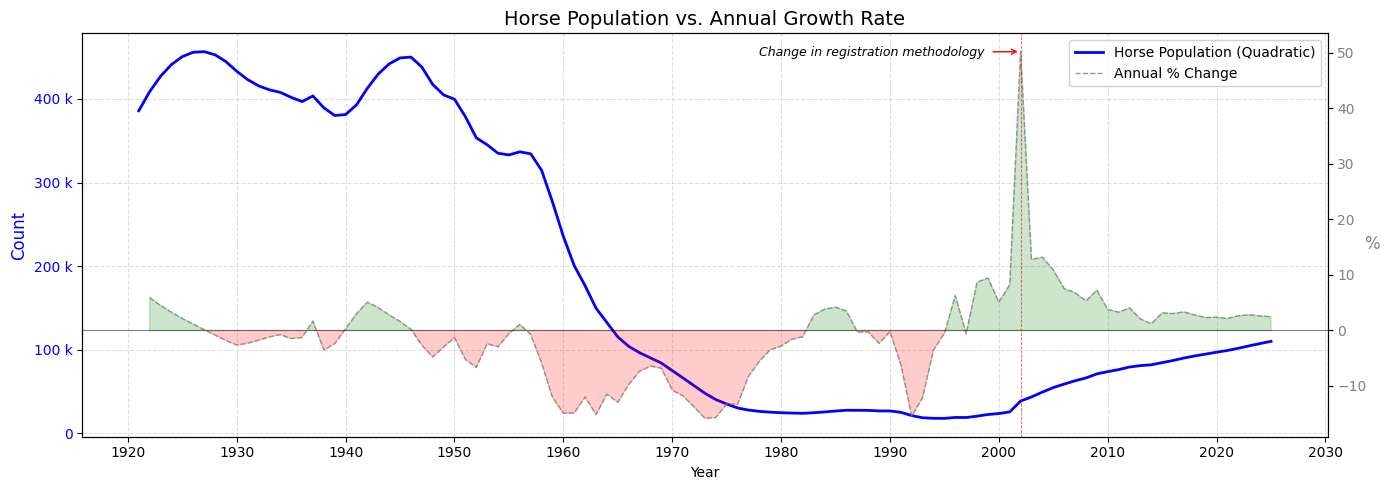

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 5))

l1 = ax1.plot(df.index, df["Horses"], label="Horse Population (Quadratic)", color="blue", linewidth=2)
ax1.set_xlabel("Year")
ax1.set_ylabel("Count", color="blue", fontsize=12)
ax1.tick_params(axis="y", labelcolor="blue")
ax1.yaxis.set_major_formatter(ticker.EngFormatter())
ax1.grid(True, linestyle="--", alpha=0.4)

ax2 = ax1.twinx()

l2 = ax2.plot(df.index, df["horse_pct_change"], label="Annual % Change", color="grey", linestyle="--", linewidth=1, alpha=0.8)
ax2.fill_between(df.index, df["horse_pct_change"], 0,
                 where=(df["horse_pct_change"] >= 0),
                 color='green', alpha=0.2, interpolate=True)
ax2.fill_between(df.index, df["horse_pct_change"], 0,
                 where=(df["horse_pct_change"] < 0),
                 color='red', alpha=0.2, interpolate=True)
ax2.set_ylabel("%", rotation=0, color="grey", fontsize=12)
ax2.tick_params(axis="y", labelcolor="grey")
ax2.axhline(0, color="black", linewidth=0.8, alpha=0.5)

ax2.annotate("Change in registration methodology",
             xy=(2002, 50.24),
             xytext=(1978, 49.5),
             arrowprops=dict(arrowstyle="->", color="red"),
             fontsize=9, color="black", backgroundcolor="none", style="italic")

ax2.axvline(x=2002, color="red", linestyle='--', linewidth=0.6, alpha=0.7)

lines = l1 + l2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right", frameon=True, facecolor="white", framealpha=0.9)

ax1.set_title("Horse Population vs. Annual Growth Rate", fontsize=14)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(10))

plt.tight_layout()
plt.show()

In [ ]:
# Exploring the period of decline and increase

df_decrease = df[df["horse_pct_change"] < 0]
decrease_diff = df_decrease.index.to_series().diff().fillna(1)
groups_decrease = (decrease_diff != 1).cumsum()

print("Periods of decline:")
for group in groups_decrease.unique():
    group_years = df_decrease.index[groups_decrease == group]
    start, end = group_years.min(), group_years.max()
    if start == end:
      print(f"- {start}")
    else:
      print(f"- {start}-{end}, (Length: {len(group_years)} years)")

Periods of decline:
- 1928-1936, (Length: 9 years)
- 1938-1939, (Length: 2 years)
- 1947-1955, (Length: 9 years)
- 1957-1982, (Length: 26 years)
- 1987-1995, (Length: 9 years)
- 1997


In [ ]:
df_increase = df[df["horse_pct_change"] > 0]
increase_diff = df_increase.index.to_series().diff().fillna(1)
groups_increase = (increase_diff != 1).cumsum()

print("Periods of increase:")
for group in groups_increase.unique():
    group_years = df_increase.index[groups_increase == group]
    start, end = group_years.min(), group_years.max()
    if start == end:
      print(f"- {start}")
    else:
      print(f"- {start}-{end}, (Length: {len(group_years)} years)")

Periods of increase:
- 1922-1927, (Length: 6 years)
- 1937
- 1940-1946, (Length: 7 years)
- 1956
- 1983-1986, (Length: 4 years)
- 1996
- 1998-2025, (Length: 28 years)


In [ ]:
df_stagnation = df[df["horse_pct_change"].abs() < 0.1]
if df_stagnation.empty:
  print("No periods of stagnation")
else:
  print(f"- Years: {df_stagnation.index.tolist()}")

No periods of stagnation


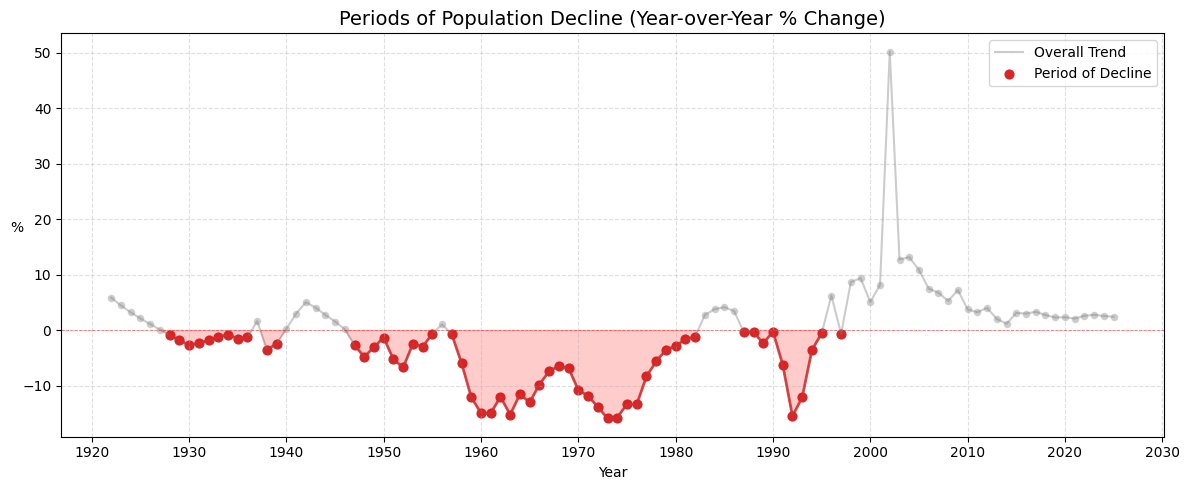

In [ ]:
plt.figure(figsize=(12, 5))

sns.lineplot(x=df.index, y=df["horse_pct_change"], color="gray", alpha=0.4, linewidth=1.5, label="Overall Trend")
sns.scatterplot(x=df.index, y=df["horse_pct_change"], color="gray", alpha=0.4, s=30)

for i, group in enumerate(groups_decrease.unique()):
    group_years = df_decrease.index[groups_decrease == group]
    subset = df["horse_pct_change"].loc[group_years]

    plt.plot(group_years, subset, color="tab:red", linewidth=2, alpha=0.8)
    label = "Period of Decline" if i == 0 else None
    plt.scatter(group_years, subset, color="tab:red", s=40, label=label)

plt.fill_between(df.index, df["horse_pct_change"], 0,
                 where=(df["horse_pct_change"] < 0),
                 color='red', alpha=0.2, interpolate=True)

plt.axhline(0, color="red", linewidth=0.6, linestyle='--', alpha=0.5)
plt.title("Periods of Population Decline (Year-over-Year % Change)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("%", rotation=0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

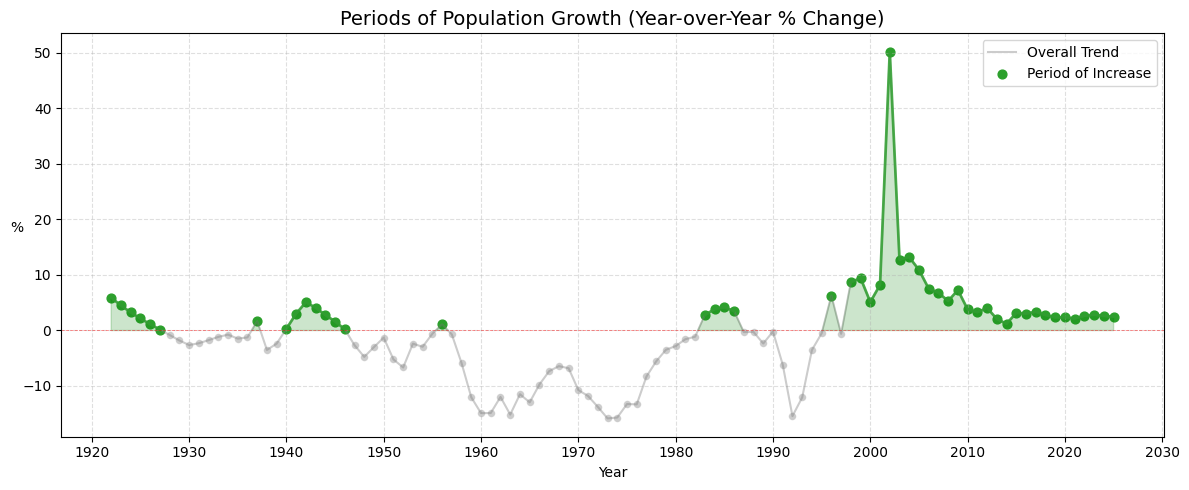

In [ ]:
plt.figure(figsize=(12, 5))

sns.lineplot(x=df.index, y=df["horse_pct_change"], color="gray", alpha=0.4, linewidth=1.5, label="Overall Trend")
sns.scatterplot(x=df.index, y=df["horse_pct_change"], color="gray", alpha=0.4, s=30)

for i, group in enumerate(groups_increase.unique()):
    group_years = df_increase.index[groups_increase == group]
    subset = df["horse_pct_change"].loc[group_years]

    plt.plot(group_years, subset, color="tab:green", linewidth=2, alpha=0.8)
    label = "Period of Increase" if i == 0 else None
    plt.scatter(group_years, subset, color="tab:green", s=40, label=label)

plt.fill_between(df.index, df["horse_pct_change"], 0,
                 where=(df["horse_pct_change"] > 0),
                 color='green', alpha=0.2, interpolate=True)

plt.axhline(0, color="red", linewidth=0.6, linestyle='--', alpha=0.5)
plt.title("Periods of Population Growth (Year-over-Year % Change)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("%", rotation=0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [ ]:
df[["Horses", "horse_pct_change", "horse_percentage_SMA_5", "horse_diff"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Horses,105.0,189142.771429,169204.254288,18039.000000,35188.000000,96541.000000,389399.000000,456486.000000
horse_pct_change,104.0,-0.869011,8.397560,-15.836803,-4.870303,-0.546980,3.079055,50.238418
horse_percentage_SMA_5,100.0,-1.047714,7.204174,-14.367262,-4.916610,-1.039872,2.714327,19.074463
horse_diff,104.0,-2650.288462,10830.519381,-41230.000000,-7566.000000,-104.000000,2634.750000,22831.000000


In [ ]:
# Search for the years when the horse population reached its peak

print("The largest population of horses was in these years:")
display(pd.DataFrame(df["Horses"].nlargest(10)).transpose())

The largest population of horses was in these years:


year,1927,1926,1928,1925,1946,1945,1929,1944,1924,1947
Horses,456486,455757,452794,450608,450000,449000,444681,441878,441038,438105


The horse population in the Czech Republic peaked during two distinct periods: the interwar period (approx. 1927) and the immediate post-war period (approx. 1946). The largest horse population was in 1927 - 456K. Note that the 1927 peak is inferred from the interpolation model.

In [ ]:
# Search for the years when the horse population reached its lowest point

print("The smallest population of horses was in these years:")
display(pd.DataFrame(df["Horses"].nsmallest(10).astype(int)).transpose())

The smallest population of horses was in these years:


year,1995,1994,1993,1997,1996,1998,1992,1999,2000,1982
Horses,18039,18131,18792,19059,19175,20718,21370,22675,23835,24127


The smallest horse population in the Czech Republic was in 1995.

In [ ]:
# The difference between the largest and the lowest population

percentage_change = ((df["Horses"].loc[1995] - df["Horses"].loc[1927]) / df["Horses"].loc[1927]) * 100
print("Between 1927 and 1995, the horse population declined by", df["Horses"].loc[1927] - df["Horses"].loc[1995], "horses")
print("The percentage of horses decreased by", round(abs(percentage_change), 2), "%")
print("This significant change has occurred over", 1995 - 1927, "years")

Between 1927 and 1995, the horse population declined by 438447 horses
The percentage of horses decreased by 96.05 %
This significant change has occurred over 68 years


From its peak in 1927 to its nadir in 1995, the horse population collapsed by 96% (a loss of approx. 438k horses). Despite the recent recovery, the 2025 population reaches only 24% of the historical maximum.

In [ ]:
# How does the current horse population (2025) differ from 1927, when the population was at its highest

percentage_change = ((df["Horses"].loc[2025] - df["Horses"].loc[1927]) / df["Horses"].loc[1927]) * 100
percentage_share = (df["Horses"].loc[2025] / df["Horses"].loc[1927]) * 100
print("Between 1927 and 2025, the horse population declined by", df["Horses"].loc[1927] - df["Horses"].loc[2025], "horses")
print(f"This represents a decline of {round(abs(percentage_change), 1)} %")
print(f"Current population represents {round(percentage_share, 1)} % of the population in 1927")

Between 1927 and 2025, the horse population declined by 346310 horses
This represents a decline of 75.9 %
Current population represents 24.1 % of the population in 1927


The current horse population (in 2025) represents 24 % of the population in 1927 (the largest population).

In [ ]:
# Finding the year with the largest percentage increase

first_pct_idx = df["horse_pct_change"].nlargest().index[0]

print("Year with the highest percentage increase:", first_pct_idx)
print("Percentage increase:", round(df["horse_pct_change"].loc[first_pct_idx], 2), "%")
print("Increase in the number of horses:", int(df["horse_diff"].loc[first_pct_idx]))

Year with the highest percentage increase: 2002
Percentage increase: 50.24 %
Increase in the number of horses: 12959


A significant structural break occurs in 2002 due to a change in registration methodology (centralized register including hobby horses). Consequently, pre-2002 data likely underestimate the total population, while post-2002 data provide a more comprehensive census.

In [ ]:
real_growth_idx = df.loc[df.index != 2002, "horse_pct_change"].idxmax()

print("Year with the second highest percentage increase:", real_growth_idx)
print("Percentage increase:", round(df["horse_pct_change"].loc[real_growth_idx], 2), "%")
print("Increase in the number of horses:", int(df["horse_diff"].loc[real_growth_idx]))

Year with the second highest percentage increase: 2004
Percentage increase: 13.21 %
Increase in the number of horses: 5774


Excluding the administrative break in 2002, the highest organic growth was recorded in 2004, with a year-over-year increase of 13%





In [ ]:
# Finding the year with the largest increase in the number of horses

first_diff_idx = df["horse_diff"].nlargest().index[0]

print("The largest increase in the number of horses was in:", first_diff_idx)
print("Increase in the number of horses:", int(df["horse_diff"].loc[first_diff_idx]))
print("Percentage increase:", round(df["horse_pct_change"].loc[first_diff_idx], 2), "%")

The largest increase in the number of horses was in: 1922
Increase in the number of horses: 22831
Percentage increase: 5.92 %


The highest increase in the number of horses was in 1922, when the population grew by 22,800 horses. Note that the 1922 peak is inferred from the interpolation model.

The periods of decline in the number of horses can be divided into three main periods.    
1) 1928 - 1939
2) 1947 - 1982
3) 1987 - 1997  
    
These are continuous periods in which a decline in the horse population prevailed.

In [ ]:
periods = [
    (1928, 1939),
    (1947, 1982),
    (1987, 1997)
]

print("Analysis of Decline Periods")

for i, (start, end) in enumerate(periods, 1):
    val_start = df["Horses"].loc[start]
    val_end = df["Horses"].loc[end]
    duration = end - start
    abs_change = val_end - val_start
    pct_change = ((val_end - val_start) / val_start) * 100

    print(f"\n{i}) Period {start} - {end}:")
    print(f"   - Duration: {duration} years")
    print(f"   - Total decrease: {abs_change} horses")
    print(f"   - Percentage drop: {pct_change:.2f} %")

Analysis of Decline Periods

1) Period 1928 - 1939:
   - Duration: 11 years
   - Total decrease: -72622 horses
   - Percentage drop: -16.04 %

2) Period 1947 - 1982:
   - Duration: 35 years
   - Total decrease: -413978 horses
   - Percentage drop: -94.49 %

3) Period 1987 - 1997:
   - Duration: 10 years
   - Total decrease: -8636 horses
   - Percentage drop: -31.18 %


The periods of growth in the number of horses can be divided into four main periods.  
1) 1922 - 1927
2) 1940 - 1946
3) 1983 - 1986
4) 1998 - present

In [ ]:
periods = [
    (1922, 1927),
    (1940, 1946),
    (1983, 1986),
    (1998, 2025)
]

print("Analysis of Population Growth")

for i, (start, end) in enumerate(periods, 1):
  val_start = df["Horses"].loc[start]
  val_end = df["Horses"].loc[end]
  duration = end - start
  abs_change = val_end - val_start
  pct_change = ((val_end - val_start) / val_start) * 100

  print(f"\n{i}) Period {start} - {end}:")
  print(f"   - Duration: {duration} years")
  print(f"   - Total increase: {abs_change} horses")
  print(f"   - Percentage rise: {pct_change:.2f} %")

Analysis of Population Growth

1) Period 1922 - 1927:
   - Duration: 5 years
   - Total increase: 47849 horses
   - Percentage rise: 11.71 %

2) Period 1940 - 1946:
   - Duration: 6 years
   - Total increase: 68677 horses
   - Percentage rise: 18.01 %

3) Period 1983 - 1986:
   - Duration: 3 years
   - Total increase: 2972 horses
   - Percentage rise: 11.98 %

4) Period 1998 - 2025:
   - Duration: 27 years
   - Total increase: 89458 horses
   - Percentage rise: 431.79 %


From 1921 to 1997, the horse population predominantly declined, with only brief periods of population growth. In 1998, the situation changed, and the population has been growing ever since (2025). As I mentioned, there was a structural break in 2002 (change in administration). The historical data likely underestimated the true population due to the exclusion of hobby horses. The post-2002 data, derived from the central register, provides a significantly more accurate and comprehensive census.

In [ ]:
# A closer look at the growth period (1998–2025)

periods = [
    (1998, 2001),
    (2003, 2025)
]

print("Phases of Growth: Organic vs. Administrative (1998–2025)")

for i, (start, end) in enumerate(periods, 1):
  val_start = df["Horses"].loc[start]
  val_end = df["Horses"].loc[end]
  duration = end - start
  abs_change = val_end - val_start
  pct_change = ((val_end - val_start) / val_start) * 100

  print(f"\n{i}) Period {start} - {end}:")
  print(f"   - Duration: {duration} years")
  print(f"   - Total increase: {abs_change} horses")
  print(f"   - Percentage rise: {pct_change:.2f} %")

# Analysis of structural break (2002)
print("\nStructural Break Analysis (2001–2002)")
val_2001 = df["Horses"].loc[2001]
val_2002 = df["Horses"].loc[2002]
jump_abs = int(val_2002 - val_2001)
jump_pct = ((val_2002 - val_2001) / val_2001) * 100

print(f"\nAdministrative Impact:")
print(f"   - Jump in records: {jump_abs} horses")
print(f"   - Artificial increase: {jump_pct:.2f} %")

Phases of Growth: Organic vs. Administrative (1998–2025)

1) Period 1998 - 2001:
   - Duration: 3 years
   - Total increase: 5077 horses
   - Percentage rise: 24.51 %

2) Period 2003 - 2025:
   - Duration: 22 years
   - Total increase: 66468 horses
   - Percentage rise: 152.07 %

Structural Break Analysis (2001–2002)

Administrative Impact:
   - Jump in records: 12959 horses
   - Artificial increase: 50.24 %


Since 2003 (following the administrative transition), the horse population has shown robust growth, increasing by 66,000 head (+152%) over the last 22 years.

In [ ]:
# Analysis of the current horse population (from 2003)

df_current = df.loc[2003:]

In [ ]:
df_current[["Horses", "horse_pct_change", "horse_percentage_SMA_5", "horse_diff"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Horses,23.0,81363.956522,18917.447376,43708.000000,68804.500000,82105.000000,96039.000000,110176.000000
horse_pct_change,23.0,4.700611,3.458436,1.209260,2.547026,3.164241,6.057603,13.210396
horse_percentage_SMA_5,23.0,6.607034,5.892358,2.462565,2.659680,2.940757,8.164026,19.074463
horse_diff,23.0,3105.304348,1208.359648,981.000000,2474.500000,2709.000000,3682.000000,5774.000000


In [ ]:
# Calculation of CAGR (Compound Annual Growth Rate)

start_val = df_current["Horses"].iloc[0]
end_val = df_current["Horses"].iloc[-1]
n_years = df_current.index.max() - df_current.index.min()

cagr = (end_val / start_val) ** (1 / n_years) - 1
cagr_pct = cagr * 100

print(f"Population in 2003: {start_val}")
print(f"Population in 2025: {end_val}")
print(f"Arithmetic Mean: {df_current['horse_pct_change'].mean():.2f} %")
print(f"CAGR: {cagr_pct:.2f} %")

Population in 2003: 43708
Population in 2025: 110176
Arithmetic Mean: 4.70 %
CAGR: 4.29 %


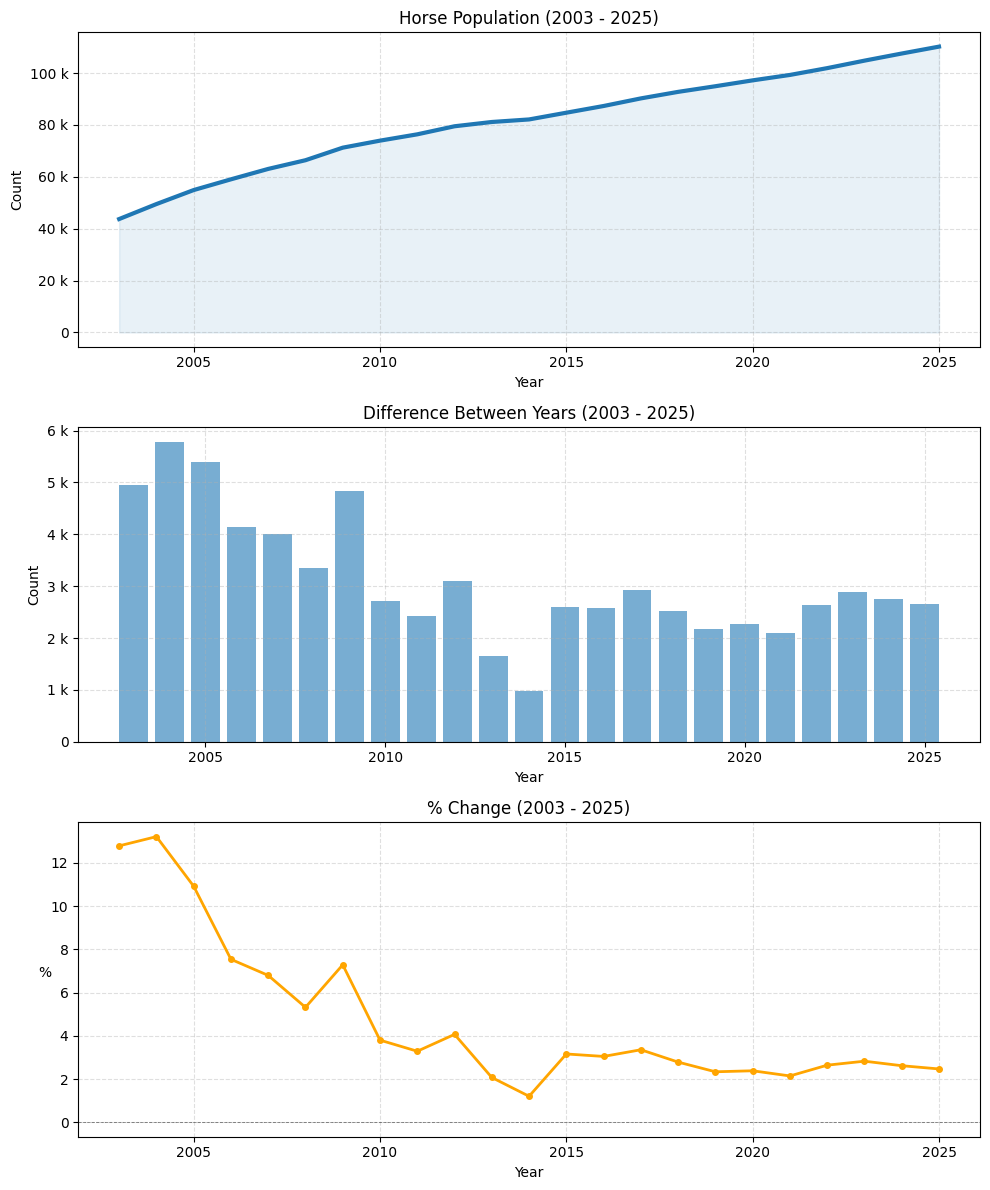

In [ ]:
labels = {
    "Horses": "Horse Population (2003 - 2025)",
    "horse_diff": "Difference Between Years (2003 - 2025)",
    "horse_pct_change": "% Change (2003 - 2025)",
}

y_labels = {
    "Horses": "Count",
    "horse_diff": "Count",
    "horse_pct_change": "%",
}

plt.figure(figsize=(10, 12))
for i, (var, lab) in enumerate(labels.items()):
  plt.subplot(3, 1, i + 1)
  if var == "horse_diff":
    plt.bar(df_current.index, df_current[var], color="tab:blue", alpha=0.6)
    plt.ylabel(y_labels.get(var))
  elif var == "Horses":
    plt.plot(df_current[var], color="tab:blue", linewidth=3)
    plt.fill_between(df_current.index, df_current[var], color="tab:blue", alpha=0.1)
    plt.ylabel(y_labels.get(var))
  else:
    plt.plot(df_current[var], color="orange", linewidth=2, marker='o', markersize=4)
    plt.axhline(0, color="black", linewidth=0.6, linestyle='--', alpha=0.5)
    plt.ylabel(y_labels.get(var), rotation=0)

  plt.title(lab, fontsize=12)
  plt.xlabel("Year")

  plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
  plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

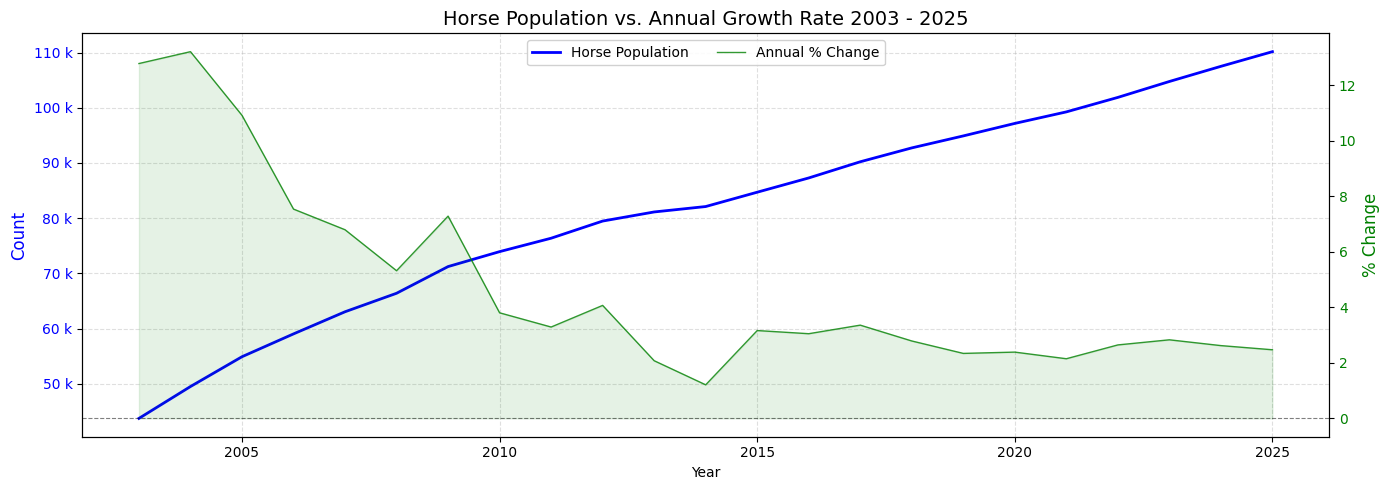

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 5))

l1 = ax1.plot(df_current.index, df_current["Horses"], label="Horse Population", color="blue", linewidth=2)

ax1.set_xlabel("Year")
ax1.set_ylabel("Count", color="blue", fontsize=12)
ax1.tick_params(axis="y", labelcolor="blue")
ax1.yaxis.set_major_formatter(ticker.EngFormatter())
ax1.grid(True, linestyle="--", alpha=0.4)

ax2 = ax1.twinx()

l2 = ax2.plot(df_current.index, df_current["horse_pct_change"], label="Annual % Change", color="green", linestyle="-", linewidth=1, alpha=0.8)

ax2.fill_between(df_current.index, df_current["horse_pct_change"], 0,
                 where=(df_current["horse_pct_change"] >= 0),
                 color='green', alpha=0.1, interpolate=True)

ax2.set_ylabel("% Change", color="green", fontsize=12)
ax2.tick_params(axis="y", labelcolor="green")

ax2.axhline(0, color="black", linewidth=0.8, alpha=0.5, linestyle="--")

lines = l1 + l2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper center", frameon=True, facecolor="white", framealpha=0.9, ncol=2)

ax1.set_title(f"Horse Population vs. Annual Growth Rate 2003 - 2025", fontsize=14)

plt.tight_layout()
plt.show()

Over the last 22 years, the horse population has exhibited a strong upward trend with a Compound Annual Growth Rate (CAGR) of 4.29 %, reaching approximately 110,000 head in 2025."

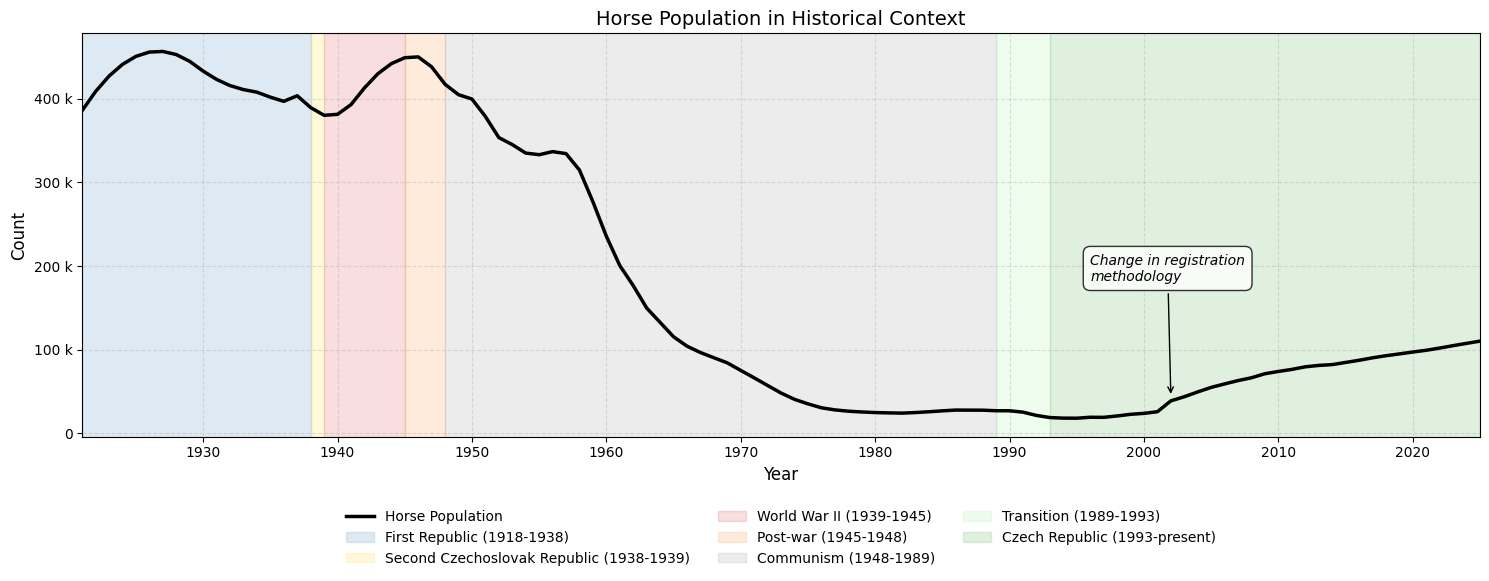

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.lineplot(x=df.index, y=df["Horses"], ax=ax, label="Horse Population", color="black", linewidth=2.5)

eras = [
    (1921, 1938, "First Republic (1918-1938)", "tab:blue"),
    (1938, 1939, "Second Czechoslovak Republic (1938-1939)", "gold"),
    (1939, 1945, "World War II (1939-1945)", "tab:red"),
    (1945, 1948, "Post-war (1945-1948)", "tab:orange"),
    (1948, 1989, "Communism (1948-1989)", "grey"),
    (1989, 1993, "Transition (1989-1993)", "lightgreen"),
    (1993, 2025, "Czech Republic (1993-present)", "tab:green")
]

for start, end, label, color in eras:
    ax.axvspan(max(start, df.index.min()), min(end, df.index.max()),
               color=color, alpha=0.15, label=label)

ax.annotate("Change in registration\nmethodology",
            xy=(2002, df["Horses"].loc[2003]),
            xytext=(1996, df["Horses"].max() * 0.4),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=10, color="black", style="italic",
            bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.8))

ax.set_title("Horse Population in Historical Context", fontsize=14)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

ax.grid(True, linestyle="--", alpha=0.4)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.set_xlim(df.index.min(), df.index.max())

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)

plt.tight_layout()
plt.show()

**4) Horse population forecast up to 2050**

The aim of this section is to create an estimate of the horse population development until 2050. I decided to compare two approaches for training the model:
1) the entire history
2) the period since 2003

In [ ]:
# Data preparation - Prophet needs a dataframe with exact columns

df_prophet = df.reset_index()
df_prophet["year"] = pd.to_datetime(df_prophet["year"], format="%Y")
df_prophet = df_prophet[["year", "Horses"]].rename(columns={"Horses": "y", "year": "ds"})

In [ ]:
df_prophet.head()

,ds,y
0,1921-01-01,385806
1,1922-01-01,408637
2,1923-01-01,427048
3,1924-01-01,441038
4,1925-01-01,450608


In [ ]:
# Create a model instance -  Forecasting 25 years ahead
"""
The model is configured to capture the long-term trend exclusively.
Seasonal components (yearly, weekly, and daily) are disabled, as the dataset consists of annual observations,
rendering such patterns inapplicable.

Model Tuning: Trend Flexibility
This analysis systematically tests various values for the changepoint_prior_scale parametr.
This parameter governs the flexibility of the model's trend component.
Lower values (e.g., 0.01) impose stronger regularization, leading to a more rigid trend (risk of underfitting).
Conversely, higher values (e.g., 0.5) result in weaker regularization, allowing the trend to adapt more
closely to historical data points (risk of overfitting).

changepoint_prior_scale value: 0.001, 0.01, 0.05, 0.1, 0.5]
"""

param_grid = [0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]

models = {}
forecasts = {}
results = []

In [ ]:
# Model instances with different settings

for scale in param_grid:
    # 1) Model instance
    model = Prophet(
        changepoint_prior_scale=scale,
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False
    )
    model.fit(df_prophet)
    models[scale] = model

    # 2) Creating future dataframes
    future = model.make_future_dataframe(periods=25, freq="YS") # Using “YS” (Year star) to start the year

    # 3) Making a prediction
    forecasts[scale] = model.predict(future)

DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/x4l6n7qn.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/wowugi5w.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=64579', 'data', 'file=/tmp/tmpdexv7m2l/x4l6n7qn.json', 'init=/tmp/tmpdexv7m2l/wowugi5w.json', 'output', 'file=/tmp/tmpdexv7m2l/prophet_modeler1wvck9/prophet_model-20260219132101.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:21:01 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:21:01 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
13:21:01 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
ERROR:cmdstanpy:Chain [1] error: error during processing Operation not permitted
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/hz4_5bg7.json
DE

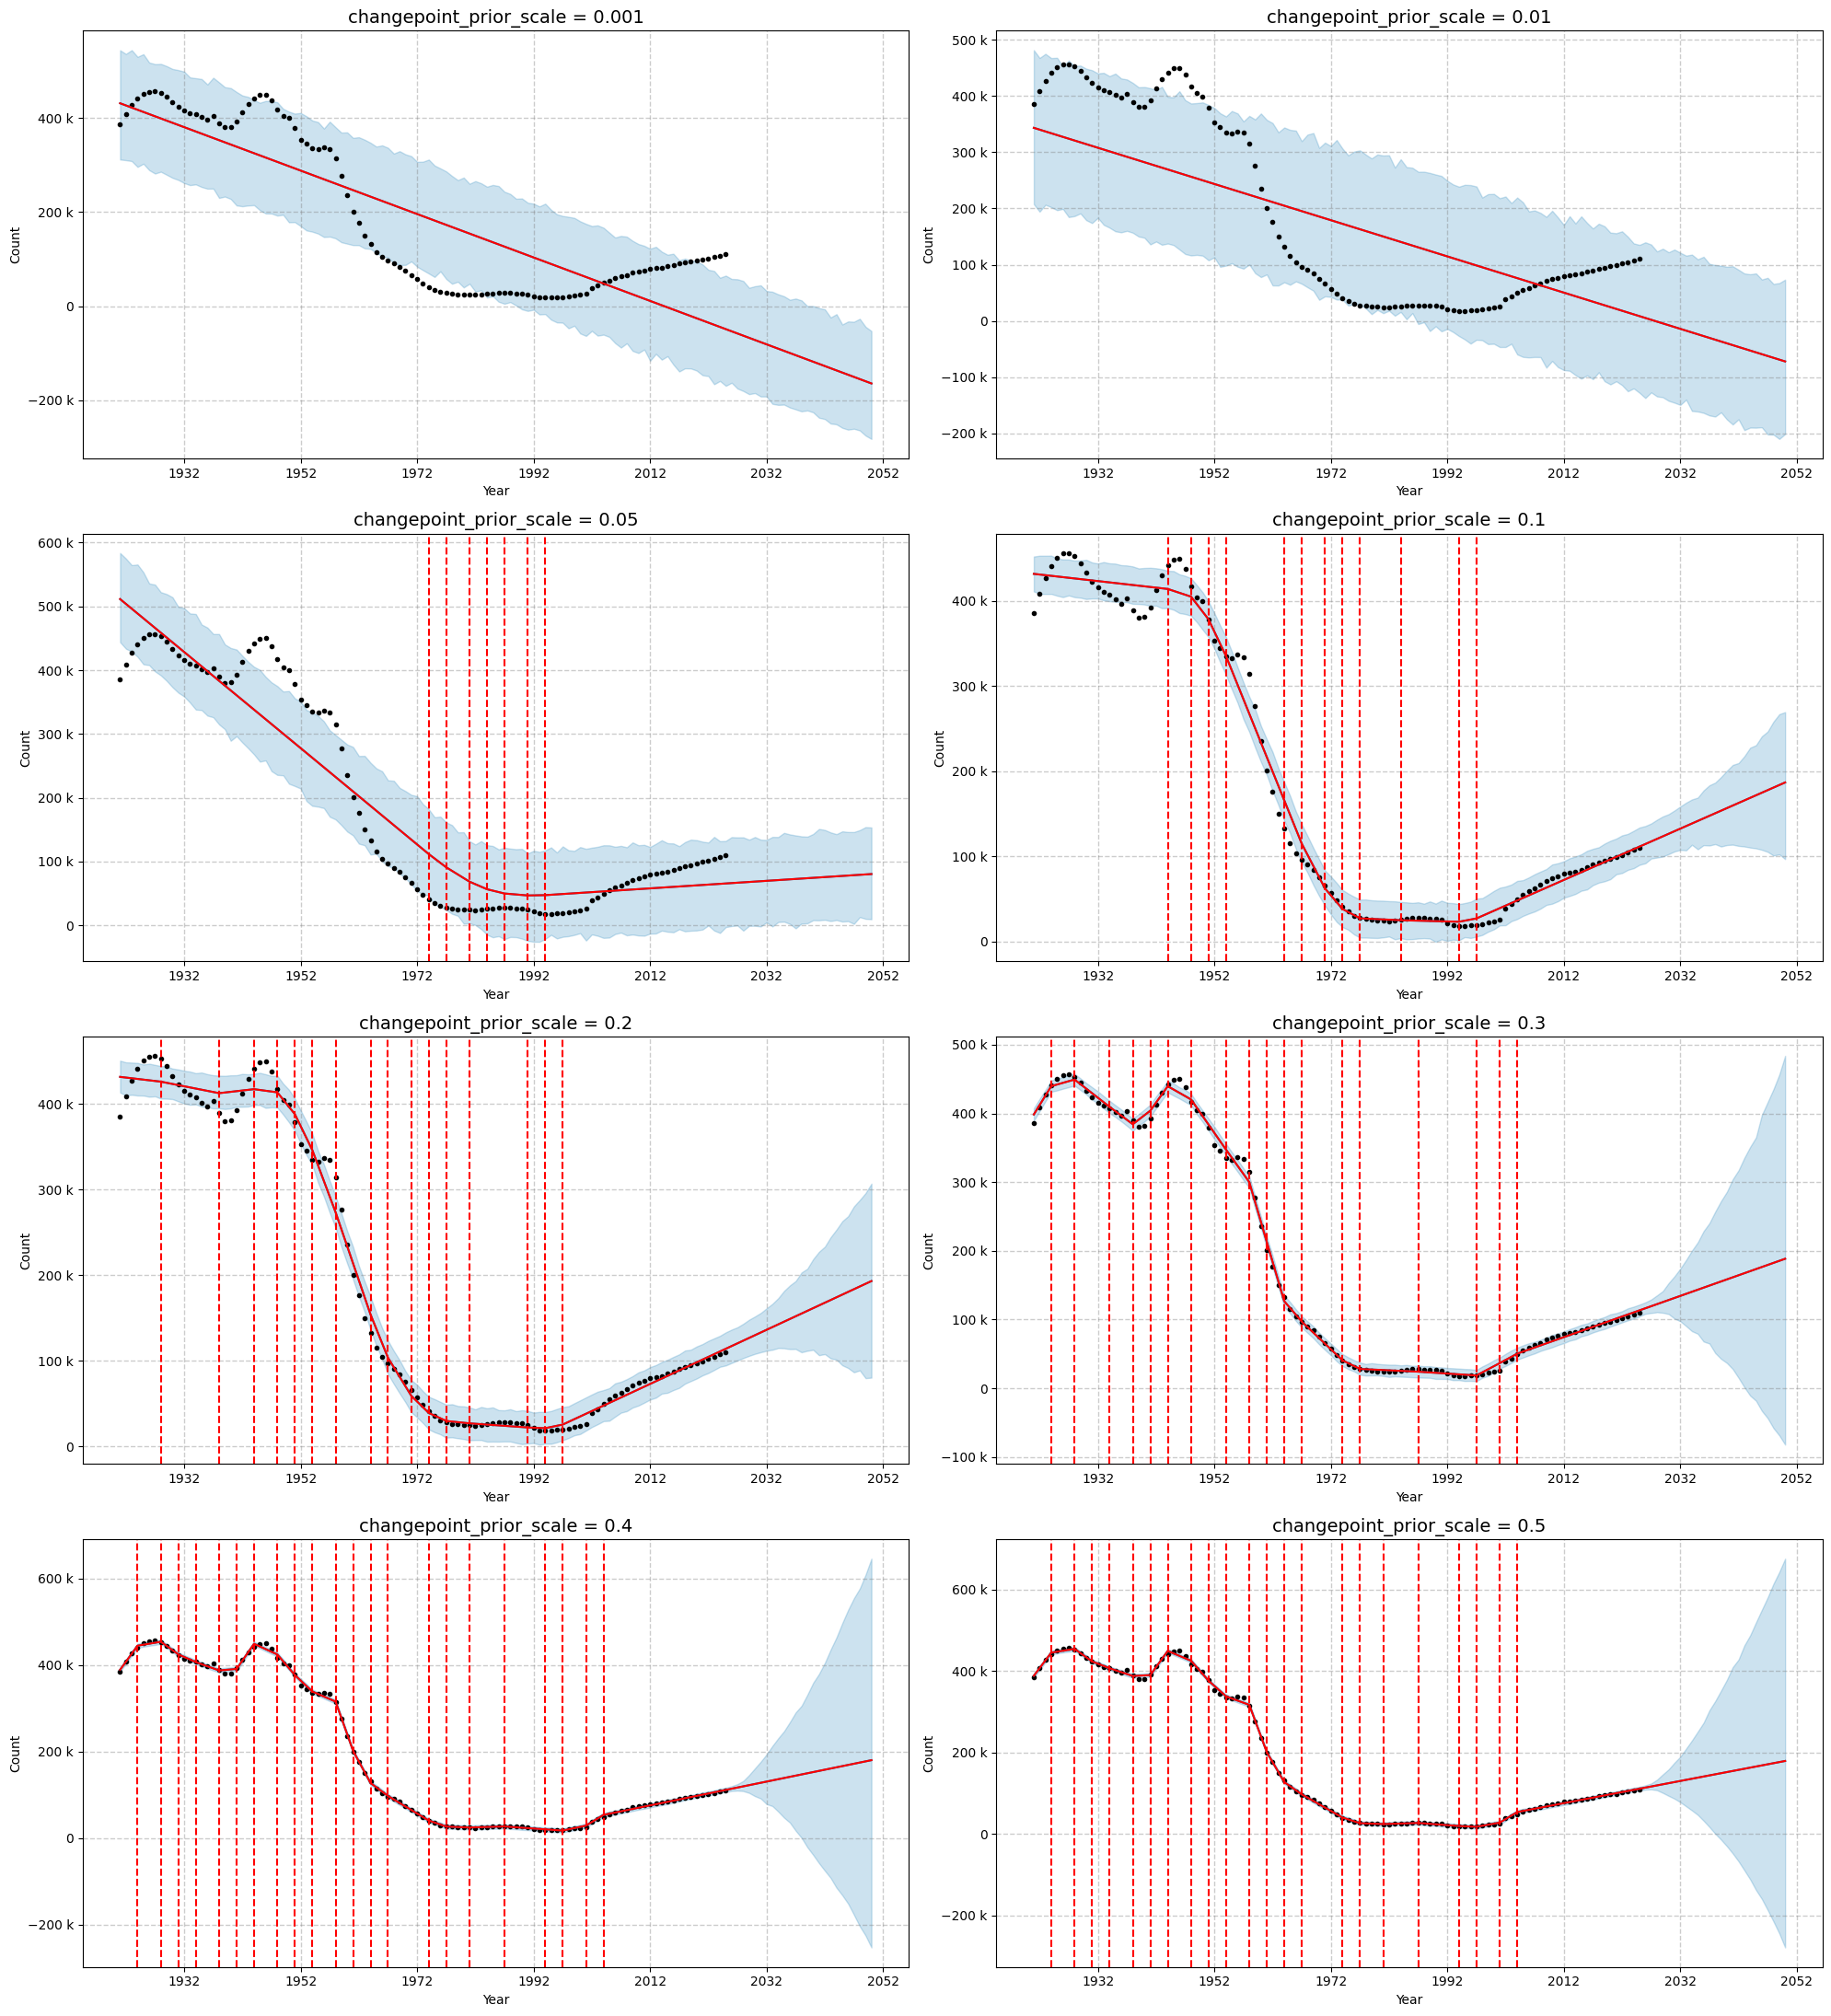

In [ ]:
# Creating visualizations
"""
Solid red line: The model's forecast.
  In the historical part, it shows how well the model fits the data (the black dots).
  In the future part, it represents the predicted future values.

The light blue area: The uncertainty interval.
  This area represents the model's confidence in its prediction.
  By default, Prophet expects 80% of the actual future data points to fall within this range.

The red dashed lines: Changepoints.
  These mark the specific dates where the model has identified a significant and change in the trend.
"""
fig, axes = plt.subplots(4, 2, figsize=(20, 22))
axes = axes.flatten()

for i, scale in enumerate(param_grid):
    ax = axes[i]
    models[scale].plot(forecasts[scale], ax=ax)
    add_changepoints_to_plot(ax, models[scale], forecasts[scale])
    ax.set_title(f"changepoint_prior_scale = {scale}", fontsize=14)
    ax.set_xlabel("Year")
    ax.set_ylabel("Count")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.yaxis.set_major_formatter(ticker.EngFormatter())

plt.tight_layout()
plt.show()

In [ ]:
# Quantitative evaluation
"""
To quantitatively evaluate the performance of each model configuration,
I performed cross-validation using Prophet's built-in functions.
This process simulates making predictions on past data to estimate how the model will perform in the future.

I use:
MAE
RMSE
MAPE (Mean Absolute Percentage Error) - Shows the average prediction error as a percentage.
Coverage - Measures the proportion of actual data points that fall within the model's predicted uncertainty interval.
"""

for scale in param_grid:
    # Cross-validation
    df_cv = cross_validation(
        models[scale],
        initial="10950 days", # 30 years
        period="3650 days", # 10 years
        horizon="3650 days", # 10 years
    )

    # Calculation of metrics
    df_p = performance_metrics(df_cv, rolling_window=1)

    # Saving the result
    results.append({
        "scale": scale,
        "mae": df_p["mae"].values[0],
        "rmse": df_p["rmse"].values[0],
        "mape": df_p["mape"].values[0],
        "coverage": df_p["coverage"].values[0]
        })

INFO:prophet:Making 7 forecasts with cutoffs between 1955-01-19 00:00:00 and 2015-01-04 00:00:00


  0%|          | 0/7 [00:00<?, ?it/s]

DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/rjhm0uwx.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/vnixfvpf.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=46257', 'data', 'file=/tmp/tmpdexv7m2l/rjhm0uwx.json', 'init=/tmp/tmpdexv7m2l/vnixfvpf.json', 'output', 'file=/tmp/tmpdexv7m2l/prophet_modeljznehhkq/prophet_model-20260219132104.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
13:21:04 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:21:04 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/_377z4ky.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/7g6okeq3.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local

  0%|          | 0/7 [00:00<?, ?it/s]

DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/hr5kacwi.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/sd4dnsdf.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=31791', 'data', 'file=/tmp/tmpdexv7m2l/hr5kacwi.json', 'init=/tmp/tmpdexv7m2l/sd4dnsdf.json', 'output', 'file=/tmp/tmpdexv7m2l/prophet_modelf7h_zfzb/prophet_model-20260219132106.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
13:21:06 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:21:06 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/_jaiq1_4.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/3qpnxahm.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local

...

DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/5_wt4eiq.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/viwor81y.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=64729', 'data', 'file=/tmp/tmpdexv7m2l/5_wt4eiq.json', 'init=/tmp/tmpdexv7m2l/viwor81y.json', 'output', 'file=/tmp/tmpdexv7m2l/prophet_model4cpwdti5/prophet_model-20260219132118.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
13:21:18 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:21:18 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/o75ujlw1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/3jbp6ri1.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local

  0%|          | 0/7 [00:00<?, ?it/s]

DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/ok1tfn45.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/lhr1ld04.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=25514', 'data', 'file=/tmp/tmpdexv7m2l/ok1tfn45.json', 'init=/tmp/tmpdexv7m2l/lhr1ld04.json', 'output', 'file=/tmp/tmpdexv7m2l/prophet_modelc9esehlz/prophet_model-20260219132121.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
13:21:21 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:21:21 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/inacxtnh.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/_xfn5gjr.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local

  0%|          | 0/7 [00:00<?, ?it/s]

DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/x1n0hguz.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/d_qthv3u.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=49222', 'data', 'file=/tmp/tmpdexv7m2l/x1n0hguz.json', 'init=/tmp/tmpdexv7m2l/d_qthv3u.json', 'output', 'file=/tmp/tmpdexv7m2l/prophet_model7h8_tzy0/prophet_model-20260219132125.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
13:21:25 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:21:25 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/7qer8y9s.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/p4vao3vh.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local

In [ ]:
df_results = pd.DataFrame(results)
display(df_results
    .sort_values(by="mae")
    .style.background_gradient(cmap="RdYlGn_r", subset=["mae", "rmse", "mape"])
                        .background_gradient(cmap="RdYlGn", subset=["coverage"])
                        .format({"mae": "{:.2f}", "rmse": "{:.2f}", "mape": "{:.2%}", "coverage": "{:.2%}"}))

,scale,mae,rmse,mape,coverage
4,0.200000,35814.42,48777.80,77.29%,61.43%
5,0.300000,38047.62,53789.95,80.51%,62.86%
6,0.400000,38308.39,54653.92,80.47%,64.29%
7,0.500000,38371.48,55098.92,80.09%,65.71%
3,0.100000,53463.83,70984.39,136.48%,31.43%
2,0.050000,114136.94,128906.95,261.72%,14.29%
1,0.010000,126555.23,142779.86,226.13%,27.14%
0,0.001000,129354.05,145620.12,231.19%,25.71%


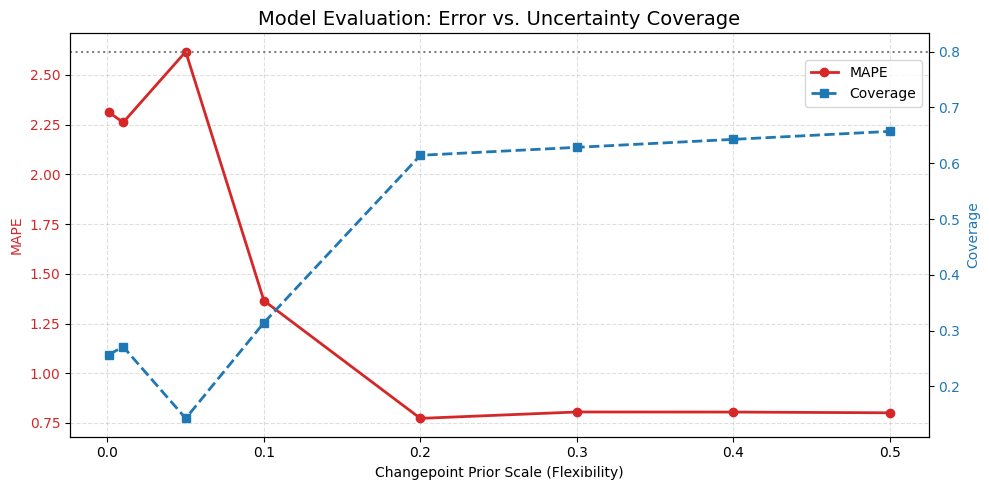

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))

l1 = ax1.plot(df_results["scale"], df_results["mape"], color="tab:red", marker="o", linewidth=2, label="MAPE")
ax1.set_xlabel("Changepoint Prior Scale (Flexibility)")
ax1.set_ylabel("MAPE", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")
ax1.grid(True, linestyle="--", alpha=0.4)

ax2 = ax1.twinx()

l2 = ax2.plot(df_results["scale"], df_results["coverage"], color="tab:blue", marker="s", linestyle="--", linewidth=2, label="Coverage")
ax2.set_ylabel("Coverage", color="tab:blue")
ax2.tick_params(axis='y', labelcolor="tab:blue")

ax2.axhline(0.80, color="grey", linestyle=":", label="Target Coverage (80%)")

lines = l1 + l2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels,
           loc="upper right",
           bbox_to_anchor=(1.0, 0.95),
           frameon=True)

plt.title("Model Evaluation: Error vs. Uncertainty Coverage", fontsize=14)
fig.tight_layout()
plt.show()

**Conclusion and Next Step**    
Cross-validation results indicate that a changepoint_prior_scale of 0.2 is optimal, achieving the lowest Mean Absolute Error (MAE).

However, despite this optimization, the model's overall predictive performance remains weak. This is evidenced by high error metrics across all configurations (MAPE > 77%) and low coverage scores, which suggests that the model fails to reliably capture the true variability of the data.

This underperformance is likely attributable to the non-stationary nature of the full historical dataset. The time series contains severe structural breaks—specifically, a period of historical dominance followed by a sharp, prolonged decline—making it difficult for a single continuous model to capture the underlying dynamics effectively.

Next Steps:   
Given the identified structural break in 2002 caused by the administrative change in methodology (central registry implementation), the most statistically sound approach is to restrict the training dataset to the period 2003-2025. This period represents a consistent, homogenous time series reflecting the modern era of horse ownership. While this reduces the dataset size, it significantly increases data quality and relevance, which is hypothesized to yield a much more accurate MAPE and reliable confidence intervals.

In [ ]:
# Data filtering - model recent
df_recent = df_prophet[df_prophet["ds"].dt.year >= 2003].copy()

models_recent = {}
forecasts_recent = {}
results_recent = []

In [ ]:
# Model instances with different settings - model recent
for scale in param_grid:
    # 1) Model instance
    model = Prophet(
        changepoint_prior_scale=scale,
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False
    )
    model.fit(df_recent)
    models_recent[scale] = model

    # 2) Creating future dataframes
    future = model.make_future_dataframe(periods=25, freq="YS")

    # 3) Making a prediction
    forecasts_recent[scale] = model.predict(future)

INFO:prophet:n_changepoints greater than number of observations. Using 17.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/6qggx9wk.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/zucqv6mn.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=47455', 'data', 'file=/tmp/tmpdexv7m2l/6qggx9wk.json', 'init=/tmp/tmpdexv7m2l/zucqv6mn.json', 'output', 'file=/tmp/tmpdexv7m2l/prophet_model6gu1v2lr/prophet_model-20260219132129.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
13:21:29 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:21:29 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:n_changepoints greater than number of observations. Using 17.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/nvl3cbr7.json
DEBUG:cmdstanpy:input tempfi

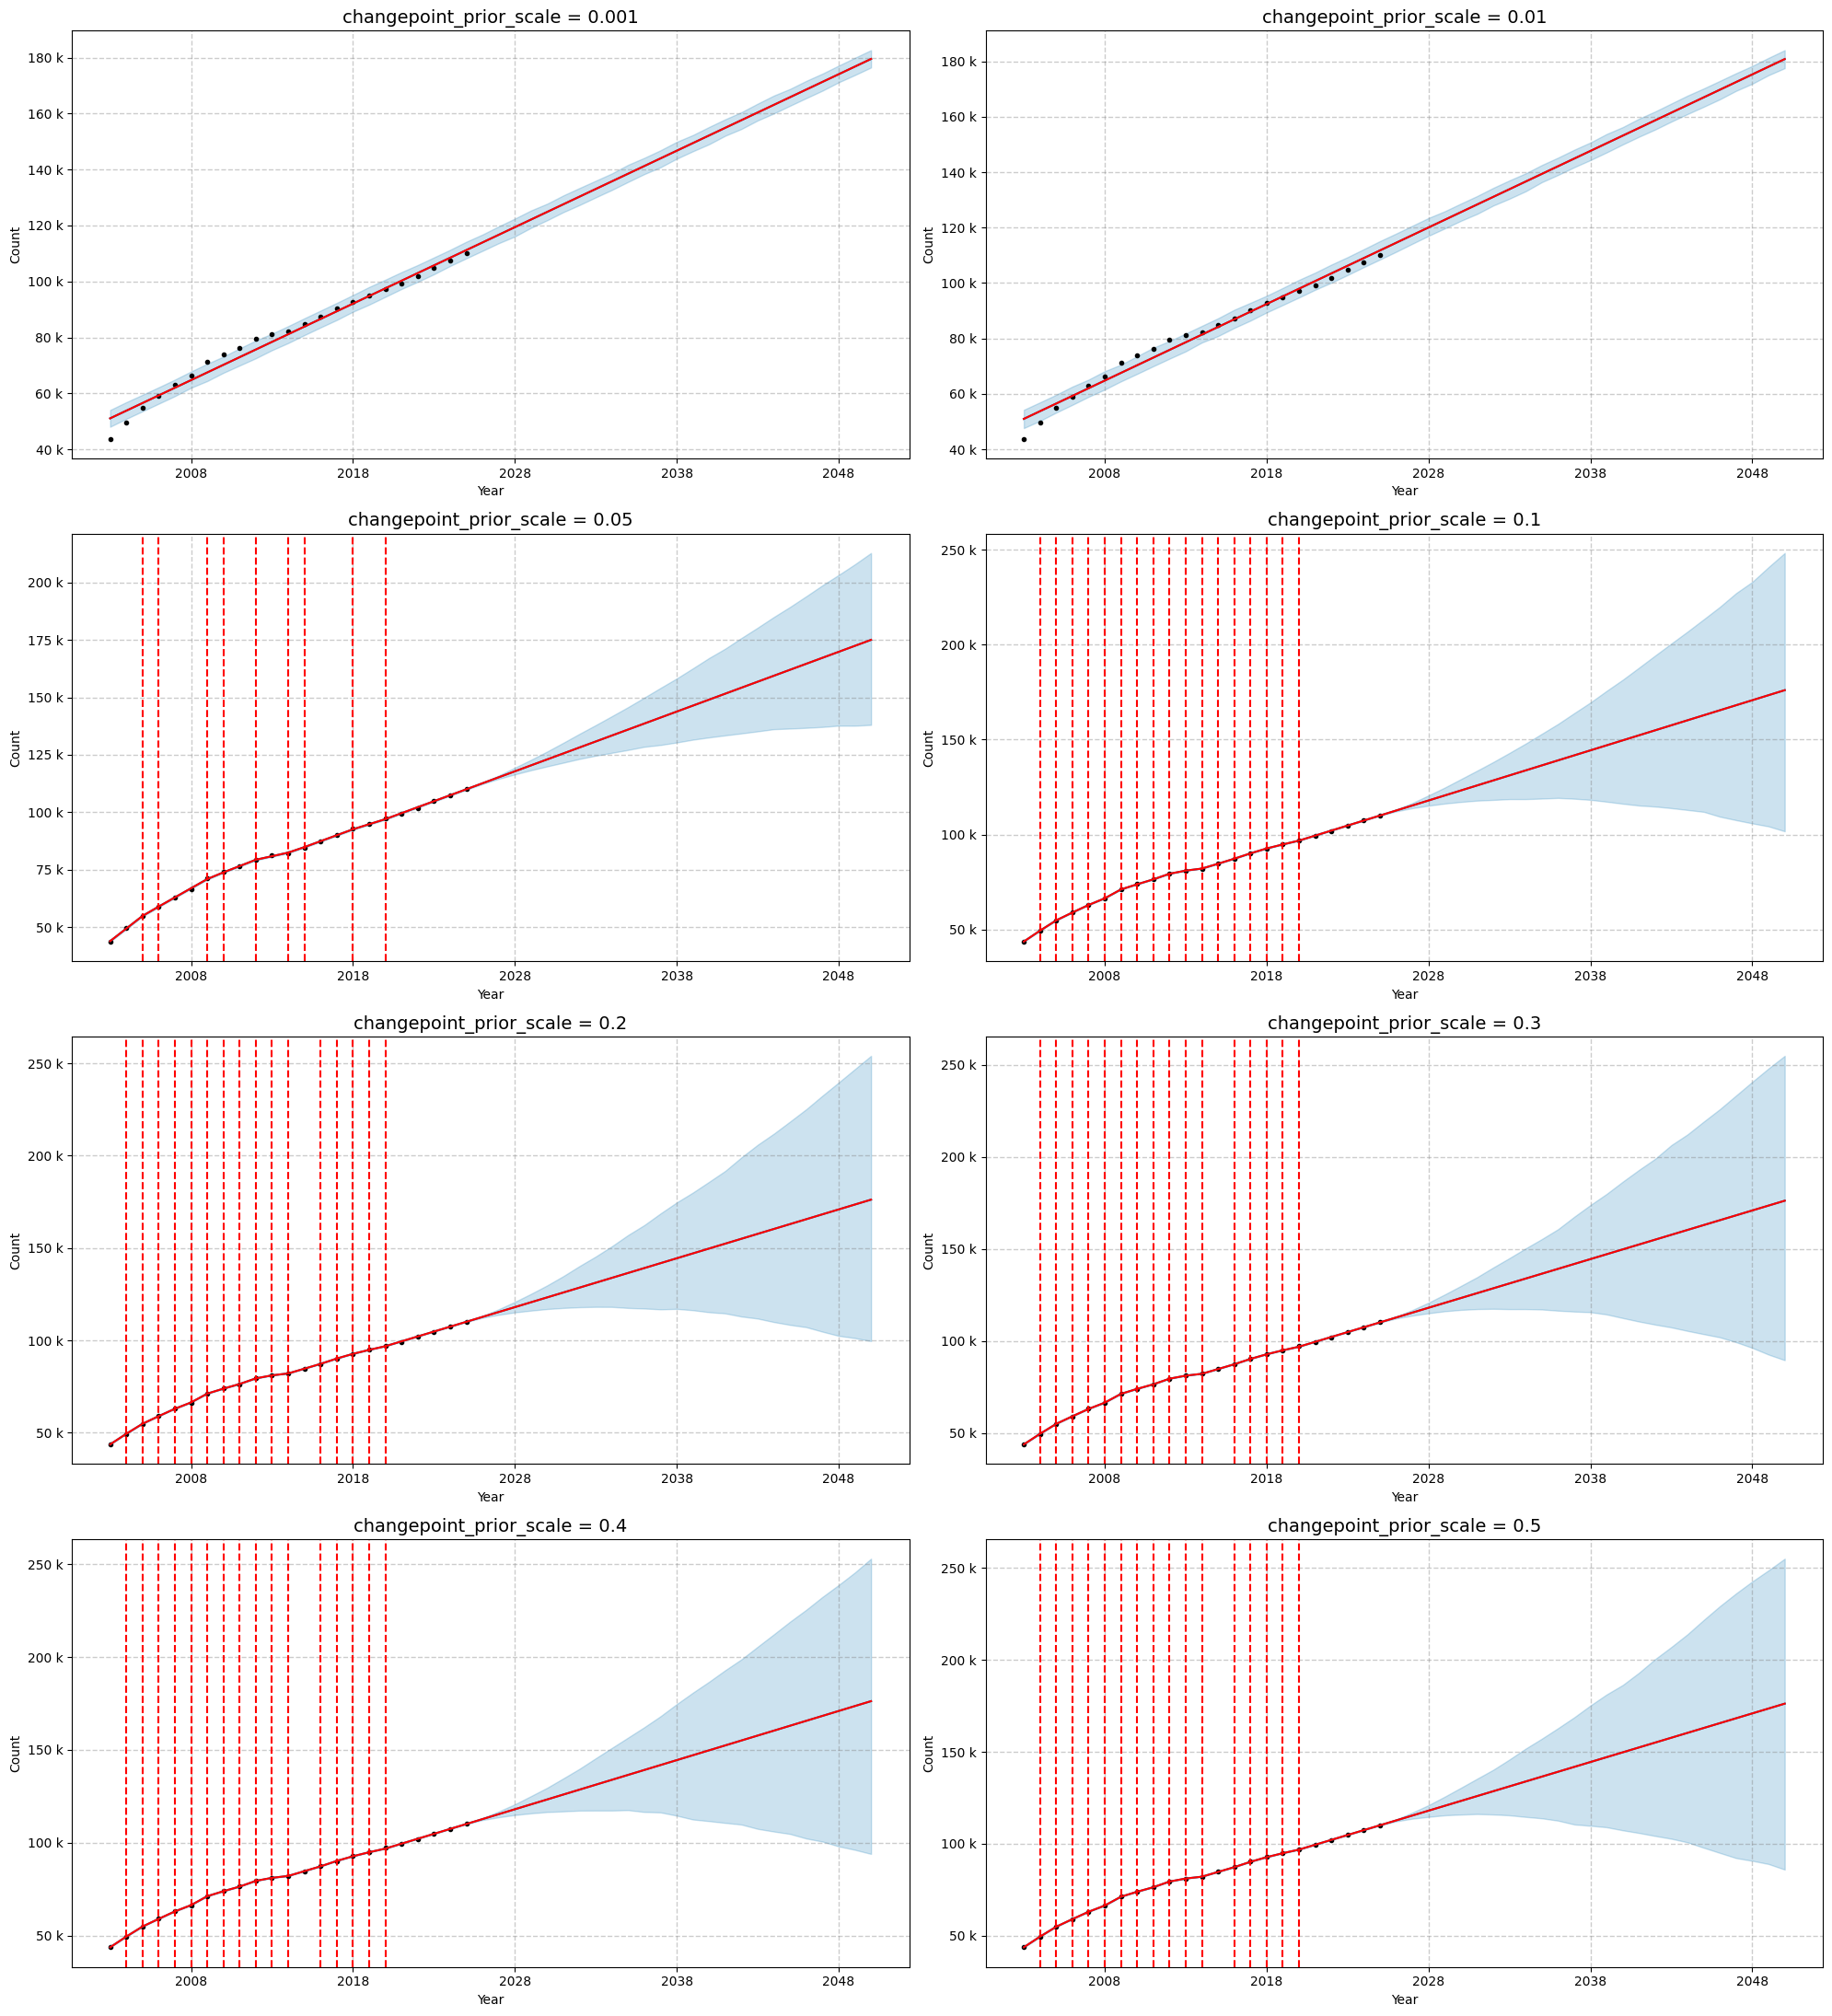

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(20, 22))
axes = axes.flatten()

for i, scale in enumerate(param_grid):
    ax = axes[i]
    models_recent[scale].plot(forecasts_recent[scale], ax=ax)
    add_changepoints_to_plot(ax, models_recent[scale], forecasts_recent[scale])
    ax.set_title(f"changepoint_prior_scale = {scale}", fontsize=14)
    ax.set_xlabel("Year")
    ax.set_ylabel("Count")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.yaxis.set_major_formatter(ticker.EngFormatter())

plt.tight_layout()
plt.show()

In [ ]:
# Quantitative evaluation of each setting - model recent

for scale in param_grid:
    # Cross validation
    df_cv = cross_validation(
        models_recent[scale],
          initial="5475 days",  # 15 years
          period="365 days",    # 1 year
          horizon="1825 days",  # 5 years
    )

    # Calculation of metrics
    df_p = performance_metrics(df_cv, rolling_window=1)

    # Saving the result
    results_recent.append({
        "scale": scale,
        "mae": df_p["mae"].values[0],
        "rmse": df_p["rmse"].values[0],
        "mape": df_p["mape"].values[0],
        "coverage": df_p["coverage"].values[0]
        })

INFO:prophet:Making 3 forecasts with cutoffs between 2018-01-03 00:00:00 and 2020-01-03 00:00:00


  0%|          | 0/3 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 11.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/hfkm4htx.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/m9ynfrkb.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=28846', 'data', 'file=/tmp/tmpdexv7m2l/hfkm4htx.json', 'init=/tmp/tmpdexv7m2l/m9ynfrkb.json', 'output', 'file=/tmp/tmpdexv7m2l/prophet_model99cywxps/prophet_model-20260219132132.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
13:21:32 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:21:32 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/l51gj_a_.json
DEBUG:cmdstanpy:input tempfi

  0%|          | 0/3 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 11.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/1i1evol2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/h4yqib4_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=71445', 'data', 'file=/tmp/tmpdexv7m2l/1i1evol2.json', 'init=/tmp/tmpdexv7m2l/h4yqib4_.json', 'output', 'file=/tmp/tmpdexv7m2l/prophet_modelcsz96bu0/prophet_model-20260219132133.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
13:21:33 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:21:33 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/7puz4qd7.json
DEBUG:cmdstanpy:input tempfi

...

INFO:prophet:n_changepoints greater than number of observations. Using 11.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/j0hx7qv9.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/xljcrzxo.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=89776', 'data', 'file=/tmp/tmpdexv7m2l/j0hx7qv9.json', 'init=/tmp/tmpdexv7m2l/xljcrzxo.json', 'output', 'file=/tmp/tmpdexv7m2l/prophet_modelser8__as/prophet_model-20260219132135.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
13:21:35 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:21:35 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/rxly6hmn.json
DEBUG:cmdstanpy:input tempfi

  0%|          | 0/3 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 11.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/hvcvreze.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/i_azl7g3.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=57629', 'data', 'file=/tmp/tmpdexv7m2l/hvcvreze.json', 'init=/tmp/tmpdexv7m2l/i_azl7g3.json', 'output', 'file=/tmp/tmpdexv7m2l/prophet_models4pxtbiv/prophet_model-20260219132135.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
13:21:35 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:21:35 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/ztwhbi1c.json
DEBUG:cmdstanpy:input tempfi

  0%|          | 0/3 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 11.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/l4rkcfqn.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/gk_tds1z.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=18528', 'data', 'file=/tmp/tmpdexv7m2l/l4rkcfqn.json', 'init=/tmp/tmpdexv7m2l/gk_tds1z.json', 'output', 'file=/tmp/tmpdexv7m2l/prophet_modelr3h9cg1b/prophet_model-20260219132136.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
13:21:36 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:21:36 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:n_changepoints greater than number of observations. Using 12.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpdexv7m2l/eoh949v8.json
DEBUG:cmdstanpy:input tempfi

In [ ]:
df_recent_results = pd.DataFrame(results_recent)
display(df_recent_results
    .sort_values(by="mae")
    .style.background_gradient(cmap="RdYlGn_r", subset=["mae", "rmse", "mape"])
                        .background_gradient(cmap="RdYlGn", subset=["coverage"])
                        .format({"mae": "{:.2f}", "rmse": "{:.2f}", "mape": "{:.2%}", "coverage": "{:.2%}"}))

,scale,mae,rmse,mape,coverage
2,0.050000,737.41,864.17,0.73%,80.00%
7,0.500000,787.05,899.46,0.78%,100.00%
6,0.400000,787.13,899.63,0.78%,100.00%
5,0.300000,787.26,899.95,0.78%,93.33%
4,0.200000,787.55,900.64,0.78%,100.00%
3,0.100000,788.25,903.49,0.78%,86.67%
0,0.001000,4225.37,4289.11,4.13%,13.33%
1,0.010000,4451.65,4510.59,4.35%,0.00%


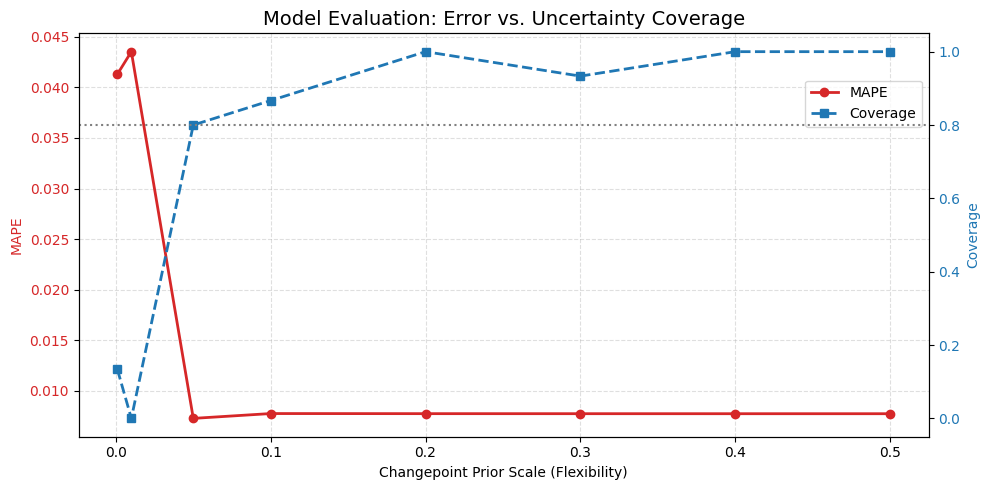

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 5))

l1 = ax1.plot(df_recent_results["scale"], df_recent_results["mape"], color="tab:red", marker="o", linewidth=2, label="MAPE")
ax1.set_xlabel("Changepoint Prior Scale (Flexibility)")
ax1.set_ylabel("MAPE", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")
ax1.grid(True, linestyle="--", alpha=0.4)

ax2 = ax1.twinx()

l2 = ax2.plot(df_recent_results["scale"], df_recent_results["coverage"], color="tab:blue", marker="s", linestyle="--", linewidth=2, label="Coverage")
ax2.set_ylabel("Coverage", color="tab:blue")
ax2.tick_params(axis='y', labelcolor="tab:blue")

ax2.axhline(0.80, color="grey", linestyle=":", label="Target Coverage (80%)")

lines = l1 + l2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels,
           loc="upper right",
           bbox_to_anchor=(1.0, 0.90),
           frameon=True)

plt.title("Model Evaluation: Error vs. Uncertainty Coverage", fontsize=14)
fig.tight_layout()
plt.show()

**Final Conclusion**   
Restricting the training dataset to the period from 2003 onwards resulted in a dramatic improvement in model performance. The Mean Absolute Error (MAE) from cross-validation dropped significantly, indicating a much more accurate fit to the recent, stable trend compared to the full historical dataset.

Based on these results, I selected changepoint_prior_scale = 0.05 as the optimal parameter. This configuration achieved the lowest MAE and RMSE values while maintaining a Coverage of exactly 80%. This indicates that the model is well-balanced—its uncertainty intervals are neither unnecessarily wide (underfitting) nor dangerously narrow (overfitting).


**Processing of the selected model**

In [ ]:
df_future_prediction = forecasts_recent[0.05].copy()

In [ ]:
df_future_prediction = (
    df_future_prediction.rename(columns={
        "ds": "year",
        "yhat": "Horses",
        "yhat_lower": "Horses_lower",
        "yhat_upper": "Horses_upper"
    })
    [["year", "Horses", "Horses_lower", "Horses_upper"]]
)

In [ ]:
df_future_prediction["year"] = df_future_prediction["year"].dt.year
df_future_prediction = df_future_prediction.set_index("year")

In [ ]:
df_future_prediction = df_future_prediction.round().astype(int)

In [ ]:
df_future_prediction.describe().T

,count,mean,std,min,25%,50%,75%,max
Horses,48.0,113899.916667,36732.903053,43867.0,84221.00,113912.0,144484.00,175056.0
Horses_lower,48.0,105920.354167,27921.534804,43577.0,83950.75,113401.0,130681.25,138029.0
Horses_upper,48.0,122437.854167,47119.599849,44145.0,84503.25,114478.5,159378.75,212896.0


In [ ]:
split_year = 2026

In [ ]:
# Merge with original df

df_full = pd.concat([df, df_future_prediction.loc[split_year:]])

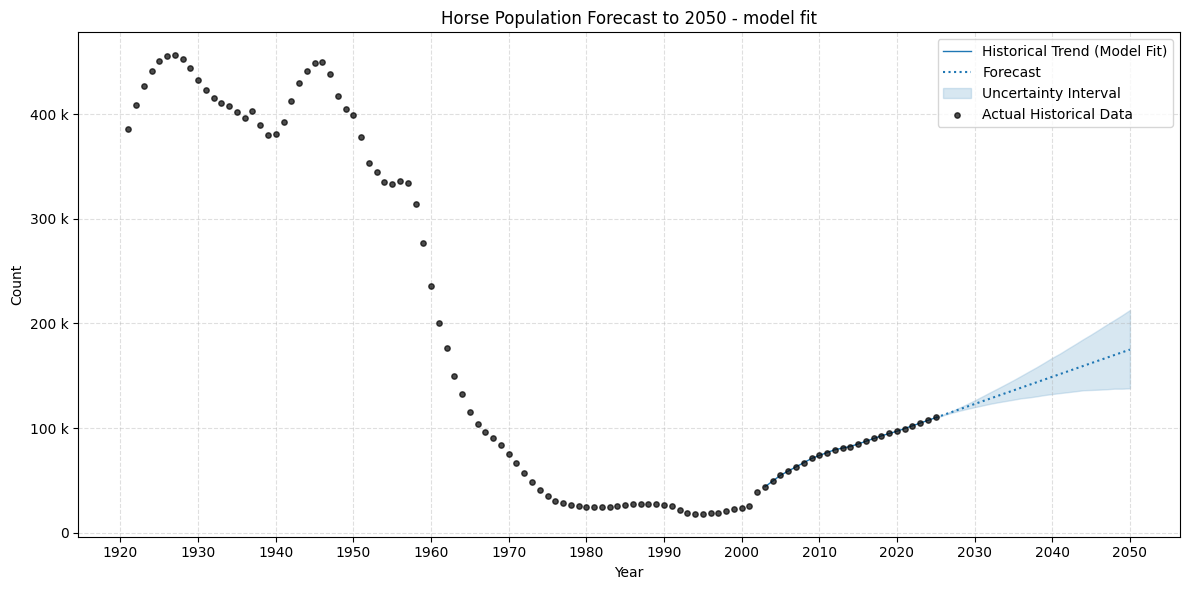

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(df_future_prediction.loc[:split_year - 1].index,
         df_future_prediction.loc[:split_year - 1, "Horses"],
         "-", color="tab:blue", linewidth=1, label="Historical Trend (Model Fit)")

plt.plot(df_future_prediction.loc[split_year - 1:].index,
         df_future_prediction.loc[split_year - 1:, "Horses"],
         ":", color="tab:blue", linewidth=1.5, label="Forecast")

plt.fill_between(
    df_future_prediction.loc[split_year - 1:].index,
    df_future_prediction.loc[split_year - 1:, "Horses_lower"],
    df_future_prediction.loc[split_year - 1:, "Horses_upper"],
    alpha=0.3,
    color="#7db0d3",
    label="Uncertainty Interval"
)

plt.scatter(df.index, df['Horses'], color="black", s=15, alpha=0.7, zorder=5, label="Actual Historical Data")

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Horse Population Forecast to 2050 - model fit")

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

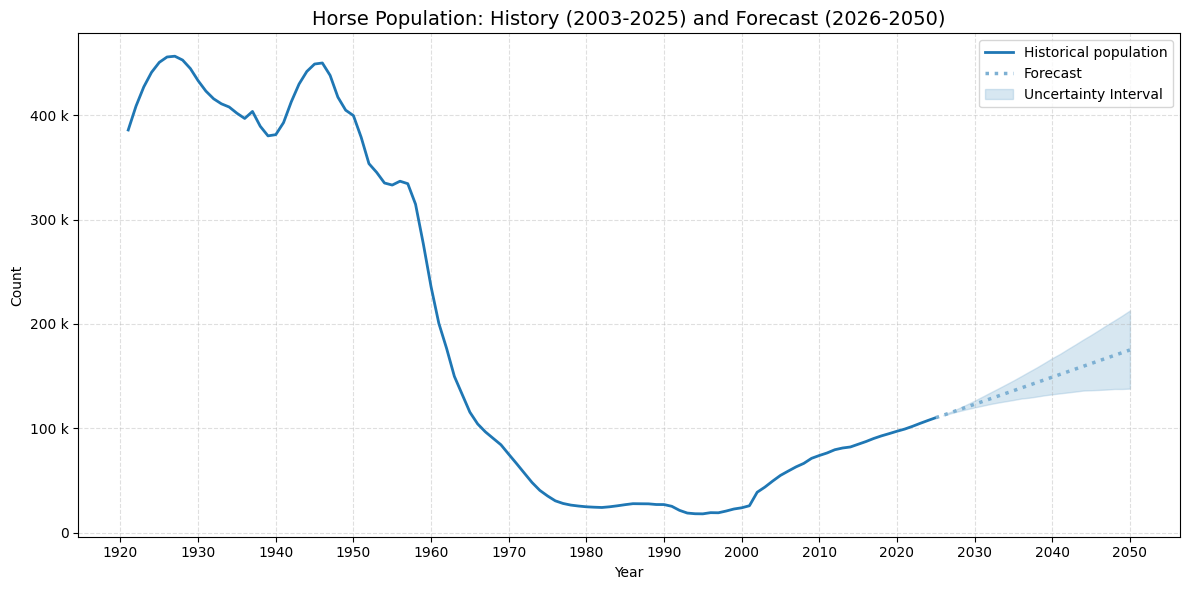

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(df_full.loc[:split_year - 1, "Horses"], "-", label="Historical population", linewidth=2)
plt.plot(df_full.loc[split_year - 1:, "Horses"], ":", label="Forecast", color="#7db0d3", linewidth=2.5)

plt.fill_between(
    df_full.loc[split_year:].index,
    df_full.loc[split_year:, "Horses_lower"],
    df_full.loc[split_year:, "Horses_upper"],
    alpha=0.3,
    color="#7db0d3",
    label="Uncertainty Interval"
)

plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Horse Population: History (2003-2025) and Forecast (2026-2050)", fontsize=14)

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

The model forecasts a continued growth trend, projecting the horse population to reach approximately 175,000 by the year 2050.

This forecast is based on a linear growth model, which assumes the growth rate observed in recent decades will persist. While this assumption may be valid for short- to medium-term predictions (5-10 years), its reliability for a long-term forecast to 2050 is uncertain.

Consequently, the long-term forecast should be interpreted with caution and viewed as a baseline scenario under the assumption of continued current trends, rather than a definitive prediction.

In [ ]:
# data saving
df_reset = df_full.reset_index()
df_reset.rename(columns={"year": "Year"}, inplace=True)
data_dict = df_reset.to_dict(orient="records")

with open("/content/drive/MyDrive/01_data_science/03_projects/01_horses_population/horse_population_analysis/data/clean_data.json", "w") as file:
    json.dump(data_dict, file, indent=4)

### Conclusion:

- There were a number of missing values in the available data on the horse population in the Czech Republic. I used quadratic polynomial interpolation to predict them and then analysed the completed time series.

- In the period under study (1921 - 2025), there was a significant decline in the number of horses.

- The highest number of horses in the Czech Republic occurred in two periods, peaking in:
  - 1927 (456 thousand horses)
  - 1946 (450 thousand horses).

- The main decline in the horse population began in 1947 and lasted 35 years (until 1982). During this period:
  - The horse population declined by 94% (414,000 horses in total).
  - The smallest size of the horse population was reached in 1995 – only 18 thousand horses in total.

- Since 1998, the horse population has been increasing, reaching 110 thousand horses in 2025.

- The rate of increase in the horse population looks stable and can be expected to continue to increase in the coming years.

***Historical view***   
The horse population has reached two peaks. The first during the First Republic and the second shortly after the Second World War. In both periods, horses were essential for agriculture and transportation. However, a gradual decline in horse numbers had already begun during the First Republic. This trend reversed during the Second World War, likely due to the increased demand for horses in wartime.   
Following the communist takeover in 1948, there was a sharp and continuous decline lasting until the mid-1990s. This was likely a direct consequence of collectivisation and widespread mechanisation, which rendered the traditional use of horses largely obsolete. After reaching a historic low in 1995, the trend reversed. Since the late 1990s, the modern era has been marked by steady growth, reflecting the horse’s transformation from a working animal to a companion used mainly for sport and recreational purposes.